> **CELL 0 — OVERVIEW: Notebook workflow and safeguards**

# Li3SiNi3O8 — Quantum ESPRESSO spin-resolved band calculation on an NVIDIA T4

This notebook is a fresh-Colab-runtime workflow for an NVIDIA T4 GPU. It uses the NVIDIA HPC SDK (`nvfortran`/`nvc`) and HPC-X MPI, downloads the official Quantum ESPRESSO **7.6** source tag, configures QE for CUDA GPU acceleration on T4 (compute capability 7.5), and builds `pw.x` and `bands.x`.

### Execution map

| Cells | Stage | Purpose |
|---|---|---|
| 3 | **Verification** | Confirm the T4 GPU and driver |
| 4 | **Environment** | Prepare NVIDIA HPC SDK, CUDA, and MPI |
| 5 | **Dependencies** | Install Python/build dependencies |
| 6 | **Configuration** | Clone QE 7.6 and configure GPU + libraries |
| 7 | **Build** | Compile `pw.x` and `bands.x` |
| 8–9 | **Verification** | Check executables and dynamic libraries |
| 11–13 | **Input / Restore** | Upload and validate the SCF backup |
| 15–17 | **Input Generation** | Create the SeekPath band path and `bands.in` |
| 19 | **GPU Calculation** | Run the expensive fixed-potential band calculation |
| 20–23 | **Post-processing / Verification** | Inspect results and generate spin-channel files |
| 25 | **Plotting** | Plot spin-up and spin-down bands |
| 27 | **Output** | Archive the final results |

The converged SCF does not need to be rerun. The existing `tmp/Li3SiNi3O8.save/` data are reused.

**Important:** QE 7.6 GPU configuration uses `--with-gpu=cuda`. This notebook retains the previously working **FFTW3** backend and uses **OpenBLAS for both BLAS and LAPACK** so that `pw.x` does not mix NVIDIA `liblapack_lp64` with system `libopenblas` at runtime.


> **CELL 1 — RUNTIME: T4 assumptions and execution strategy**

## 0. T4 runtime assumptions

Use **Runtime → Change runtime type → T4 GPU** before running the notebook.

This workflow uses:

- **MPI ranks (`NP`) = 1**
- **GPU = 1 × NVIDIA T4**
- **OpenMP threads = 1**
- **OpenBLAS threads = 1**
- **T4 compute capability = 7.5**

The single-thread CPU setting is deliberate. The previous segmentation fault occurred in complex LAPACK/OpenBLAS diagonalization, so the runtime keeps the host-side linear-algebra stack single-threaded while the GPU performs the CUDA-accelerated work.


> **CELL 2 — FIX SUMMARY: Current corrections**

## Fixes applied

1. QE 7.6 is cloned automatically when `/content/q-e-qe-7.6` is absent.
2. GPU configuration uses `--with-gpu=cuda --with-cuda-runtime=12.9 --with-cuda-cc=75`.
3. The CUDA detector selects a real versioned toolkit containing `nvcc` and `lib64` and prefers CUDA 12.9 when it is installed.
4. The previously working FFTW3 backend is retained: `-lfftw3_omp -lfftw3`.
5. BLAS and LAPACK are both set to OpenBLAS: `-lopenblas`.
6. The build stage checks that `pw.x` is not linked to NVIDIA `liblapack_lp64` before any long calculation is launched.
7. The runtime uses NVIDIA `libnvomp.so` via `LD_PRELOAD`, but does not prepend the NVHPC compiler library directory to `LD_LIBRARY_PATH`.
8. Host-side OpenMP/OpenBLAS threading is fixed at 1 for the expensive QE run.


In [ ]:
# CELL 3 — VERIFICATION: GPU hardware and driver check

# Check that this is really a GPU runtime and inspect the T4.
!nvidia-smi
!echo
!nvidia-smi --query-gpu=name,compute_cap,memory.total,driver_version --format=csv
!echo
!python --version
!nproc


Tue Sep 22 05:23:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             69W /   70W |    1821MiB /  15360MiB |    100%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# CELL 4 — ENVIRONMENT: NVIDIA HPC SDK + CUDA + HPC-X MPI

import os, glob, pathlib, subprocess, re

# CPU/GPU development dependencies used by QE and this notebook.
subprocess.run(
    [
        "bash", "-lc",
        "apt-get update -qq && "
        "DEBIAN_FRONTEND=noninteractive apt-get install -y -qq "
        "curl ca-certificates gnupg git make cmake "
        "libfftw3-dev libopenblas-dev liblapack-dev",
    ],
    check=True,
)

# ------------------------------------------------------------
# Locate or install NVIDIA HPC SDK
# ------------------------------------------------------------
NVHPC_MATCHES = [
    p for p in glob.glob("/opt/nvidia/hpc_sdk/**/nvfortran", recursive=True)
    if os.path.isfile(p)
]

if not NVHPC_MATCHES:
    print("NVIDIA HPC SDK not found; installing NVIDIA HPC SDK 25.5...")
    subprocess.run(
        [
            "bash", "-lc",
            "set -e; "
            "curl -fsSL https://developer.download.nvidia.com/hpc-sdk/ubuntu/DEB-GPG-KEY-NVIDIA-HPC-SDK "
            "| gpg --dearmor -o /usr/share/keyrings/nvidia-hpcsdk-archive-keyring.gpg; "
            "echo 'deb [signed-by=/usr/share/keyrings/nvidia-hpcsdk-archive-keyring.gpg] "
            "https://developer.download.nvidia.com/hpc-sdk/ubuntu/amd64 /' "
            "> /etc/apt/sources.list.d/nvhpc.list; "
            "apt-get update -qq; "
            "DEBIAN_FRONTEND=noninteractive apt-get install -y -qq nvhpc-25-5",
        ],
        check=True,
    )
    NVHPC_MATCHES = [
        p for p in glob.glob("/opt/nvidia/hpc_sdk/**/nvfortran", recursive=True)
        if os.path.isfile(p)
    ]

if not NVHPC_MATCHES:
    raise RuntimeError("Could not find nvfortran under /opt/nvidia/hpc_sdk.")

nvfortran = sorted(NVHPC_MATCHES)[-1]
NVHPC_ROOT = str(pathlib.Path(nvfortran).parents[2])

# ------------------------------------------------------------
# Select CUDA 12.9 when available; otherwise use the newest
# versioned CUDA toolkit containing nvcc + lib64.
# ------------------------------------------------------------
cuda_candidates = []
for p in glob.glob(os.path.join(NVHPC_ROOT, "cuda", "*")):
    if (
        os.path.isfile(os.path.join(p, "bin", "nvcc"))
        and os.path.isdir(os.path.join(p, "lib64"))
        and re.fullmatch(r"\d+\.\d+", os.path.basename(p))
    ):
        cuda_candidates.append(p)

if not cuda_candidates:
    raise RuntimeError(f"No versioned CUDA toolkit found under {NVHPC_ROOT}/cuda")

preferred_cuda = os.path.join(NVHPC_ROOT, "cuda", "12.9")
if preferred_cuda in cuda_candidates:
    CUDA_DIR = preferred_cuda
else:
    CUDA_DIR = sorted(
        cuda_candidates,
        key=lambda x: tuple(map(int, os.path.basename(x).split("."))),
    )[-1]

CUDA_RUNTIME = os.path.basename(CUDA_DIR)

# ------------------------------------------------------------
# HPC-X MPI
# ------------------------------------------------------------
hpcx_matches = glob.glob(
    os.path.join(
        NVHPC_ROOT, "comm_libs", "*", "hpcx", "hpcx-*", "hpcx-init.sh"
    )
)
if not hpcx_matches:
    raise RuntimeError("Could not find NVIDIA HPC-X MPI inside the NVIDIA HPC SDK.")

HPCX_INIT = sorted(hpcx_matches)[-1]
MPI_BIN = os.path.join(NVHPC_ROOT, "comm_libs", "mpi", "bin")

if not os.path.exists(os.path.join(MPI_BIN, "mpif90")):
    raise RuntimeError(f"Expected MPI wrapper not found: {MPI_BIN}/mpif90")

QE_GPU_CC = "75"  # NVIDIA T4

# ------------------------------------------------------------
# Shared QE environment script
# ------------------------------------------------------------
env_script = f'''#!/bin/bash
set -e

export NVHPC_ROOT="{NVHPC_ROOT}"
export NVHPC_CUDA_HOME="{CUDA_DIR}"
export NVCOMPILER_CUDA_HOME="{CUDA_DIR}"
export NVCOMPILER_COMM_LIBS_HOME="{os.path.join(NVHPC_ROOT, "comm_libs", CUDA_RUNTIME)}"
export QE_CUDA_RUNTIME="{CUDA_RUNTIME}"
export QE_GPU_CC="{QE_GPU_CC}"
export QE_ROOT="/content/q-e-qe-7.6"

source "{HPCX_INIT}"
hpcx_load >/dev/null 2>&1

export PATH="{MPI_BIN}:$NVHPC_ROOT/compilers/bin:$NVHPC_CUDA_HOME/bin:$PATH"

export LD_LIBRARY_PATH="\\
$NVHPC_ROOT/comm_libs/mpi/lib:\\
$NVHPC_ROOT/comm_libs/{CUDA_RUNTIME}/lib:\\
$NVHPC_CUDA_HOME/lib64:\\
$NVHPC_ROOT/math_libs/{CUDA_RUNTIME}/lib:\\
$NVHPC_ROOT/math_libs/lib64:\\
$LD_LIBRARY_PATH"

export CC=nvc
export CXX=nvc++
export F90=nvfortran
export F77=nvfortran
export FC=nvfortran
export MPIF90=mpif90

export OMPI_CC=nvc
export OMPI_CXX=nvc++
export OMPI_FC=nvfortran
export OMPI_ALLOW_RUN_AS_ROOT=1
export OMPI_ALLOW_RUN_AS_ROOT_CONFIRM=1

export CUDA_HOME="$NVHPC_CUDA_HOME"
export CUDA_VISIBLE_DEVICES=0
export USEGPU=yes

# Stable host-side numerical threading defaults.
export OMP_NUM_THREADS=1
export OMP_THREAD_LIMIT=1
export OPENBLAS_NUM_THREADS=1
export GOTO_NUM_THREADS=1
export BLIS_NUM_THREADS=1
export MKL_NUM_THREADS=1
'''

pathlib.Path("/content/qe_gpu_env.sh").write_text(env_script)
os.chmod("/content/qe_gpu_env.sh", 0o755)
pathlib.Path("/content/qe_root.txt").write_text("/content/q-e-qe-7.6\n")

subprocess.run(
    [
        "bash", "-lc",
        r'''
source /content/qe_gpu_env.sh
printf 'NVHPC_ROOT=%s\n' "$NVHPC_ROOT"
printf 'NVHPC_CUDA_HOME=%s\n' "$NVHPC_CUDA_HOME"
printf 'QE_CUDA_RUNTIME=%s\n' "$QE_CUDA_RUNTIME"
printf 'QE_GPU_CC=%s\n' "$QE_GPU_CC"
printf 'CUDA_VISIBLE_DEVICES=%s\n' "$CUDA_VISIBLE_DEVICES"
printf 'OMP_NUM_THREADS=%s\n' "$OMP_NUM_THREADS"
printf 'OPENBLAS_NUM_THREADS=%s\n' "$OPENBLAS_NUM_THREADS"
which nvfortran
nvfortran --version | head -3
which mpif90
which mpirun
mpif90 --showme:command 2>/dev/null || mpif90 -show 2>/dev/null || true
nvidia-smi --query-gpu=name,compute_cap,memory.total,driver_version --format=csv
''',
    ],
    check=True,
)


CompletedProcess(args=['bash', '-lc', '\nsource /content/qe_gpu_env.sh\nprintf \'NVHPC_ROOT=%s\\n\' "$NVHPC_ROOT"\nprintf \'NVHPC_CUDA_HOME=%s\\n\' "$NVHPC_CUDA_HOME"\nprintf \'QE_CUDA_RUNTIME=%s\\n\' "$QE_CUDA_RUNTIME"\nprintf \'QE_GPU_CC=%s\\n\' "$QE_GPU_CC"\nprintf \'CUDA_VISIBLE_DEVICES=%s\\n\' "$CUDA_VISIBLE_DEVICES"\nprintf \'OMP_NUM_THREADS=%s\\n\' "$OMP_NUM_THREADS"\nprintf \'OPENBLAS_NUM_THREADS=%s\\n\' "$OPENBLAS_NUM_THREADS"\nwhich nvfortran\nnvfortran --version | head -3\nwhich mpif90\nwhich mpirun\nmpif90 --showme:command 2>/dev/null || mpif90 -show 2>/dev/null || true\nnvidia-smi --query-gpu=name,compute_cap,memory.total,driver_version --format=csv\n'], returncode=0)

In [ ]:
# CELL 5 — DEPENDENCIES: Python packages for k-path generation

# Python packages used to generate the crystallographic high-symmetry path
!pip -q install seekpath spglib


In [ ]:
# CELL 6 — CONFIGURATION: Clone and configure QE 7.6

import os
import subprocess
from pathlib import Path

QE = Path("/content/q-e-qe-7.6")

# Load the same NVHPC/HPC-X environment used by the compiler.
probe = subprocess.run(
    ["bash", "-lc", "source /content/qe_gpu_env.sh && env"],
    text=True,
    stdout=subprocess.PIPE,
    check=True,
)

env = os.environ.copy()
for line in probe.stdout.splitlines():
    if "=" in line:
        k, v = line.split("=", 1)
        env[k] = v

# Keep the numerical libraries consistent.
env.update({
    "BLAS_LIBS": "-lopenblas",
    "LAPACK_LIBS": "-lopenblas",
    "FFTW_INCLUDE": "/usr/include",
    "FFT_LIBS": "-lfftw3_omp -lfftw3",
    "OMP_NUM_THREADS": "1",
    "OMP_THREAD_LIMIT": "1",
    "OPENBLAS_NUM_THREADS": "1",
    "GOTO_NUM_THREADS": "1",
    "BLIS_NUM_THREADS": "1",
    "MKL_NUM_THREADS": "1",
})

# ------------------------------------------------------------
# Download official QE 7.6 source when absent.
# ------------------------------------------------------------
if not QE.exists():
    print("QE 7.6 source not found. Cloning official qe-7.6 tag...")
    subprocess.run(
        [
            "git", "clone", "--depth", "1", "--branch", "qe-7.6",
            "https://gitlab.com/QEF/q-e.git", str(QE)
        ],
        check=True,
    )

if not (QE / "configure").exists():
    raise RuntimeError(f"QE configure script not found in {QE}")

print("QE source:", QE)
print("CUDA runtime:", env.get("QE_CUDA_RUNTIME"))
print("GPU compute capability: cc75")

# ------------------------------------------------------------
# Preflight the CUDA-Fortran 'cudafor' module. This catches the
# exact configure failure before QE configuration is attempted.
# ------------------------------------------------------------
testdir = QE / "_cudafor_test"
testdir.mkdir(exist_ok=True)
test_f90 = testdir / "test_cudafor.f90"
test_f90.write_text(
    """
program test_cudafor
  use cudafor
  implicit none
  print *, "CUDA Fortran / cudafor module OK"
end program test_cudafor
"""
)

p = subprocess.run(
    [
        "nvfortran", "-cuda",
        f"-gpu=cuda{env['QE_CUDA_RUNTIME']}",
        str(test_f90), "-o", str(testdir / "test_cudafor")
    ],
    env=env,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)

print("\n========== CUDA-FORTRAN PREFLIGHT ==========")
print(p.stdout)

if p.returncode != 0:
    raise RuntimeError(
        "nvfortran could not compile a CUDA-Fortran cudafor test. "
        "QE configure was not attempted."
    )

print("CUDA-Fortran preflight PASSED.")

# ------------------------------------------------------------
# Remove stale configuration/build products.
# ------------------------------------------------------------
subprocess.run(
    ["make", "clean"], cwd=QE,
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=False
)
for stale in ["config.cache", "make.inc"]:
    fp = QE / stale
    if fp.exists():
        fp.unlink()

# ------------------------------------------------------------
# QE 7.6 configure.
# IMPORTANT: --with-gpu=cuda is the GPU switch for QE 7.6.
# ------------------------------------------------------------
configure_cmd = [
    "./configure",
    "CC=nvc", "CXX=nvc++",
    "F90=nvfortran", "FC=nvfortran", "F77=nvfortran", "MPIF90=mpif90",
    "--with-gpu=cuda",
    f"--with-cuda-runtime={env['QE_CUDA_RUNTIME']}",
    "--with-cuda-cc=75",
    "--enable-openmp",
    "--with-scalapack=no",
]

print("\n========== QE 7.6 CONFIGURATION ==========")
print(" ".join(configure_cmd))
print("\nBLAS_LIBS   =", env["BLAS_LIBS"])
print("LAPACK_LIBS =", env["LAPACK_LIBS"])
print("FFT_LIBS    =", env["FFT_LIBS"])

p = subprocess.run(
    configure_cmd,
    cwd=QE,
    env=env,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)
print(p.stdout)

if p.returncode != 0:
    raise RuntimeError(f"QE configure failed with code {p.returncode}")

makeinc = QE / "make.inc"
if not makeinc.exists():
    raise RuntimeError("QE configure reported success but make.inc is missing.")

txt = makeinc.read_text(errors="ignore")
print("\n========== GENERATED make.inc (RELEVANT SETTINGS) ==========")
for line in txt.splitlines():
    if any(k in line for k in [
        "DFLAGS", "IFLAGS", "BLAS_LIBS", "LAPACK_LIBS", "FFT_LIBS", "CUDA"
    ]):
        print(line)

Path("/content/qe_make.inc_configured").write_text(txt)
print("\n✅ QE 7.6 configuration completed. Proceed to Cell 7 (Build).")


QE source: /content/q-e-qe-7.6
CUDA runtime: 12.9
GPU compute capability: cc75

========== CUDA-FORTRAN PREFLIGHT ==========

CUDA-Fortran preflight PASSED.

========== QE 7.6 CONFIGURATION ==========
./configure CC=nvc CXX=nvc++ F90=nvfortran FC=nvfortran F77=nvfortran MPIF90=mpif90 --with-gpu=cuda --with-cuda-runtime=12.9 --with-cuda-cc=75 --enable-openmp --with-scalapack=no

BLAS_LIBS   = -lopenblas
LAPACK_LIBS = -lopenblas
FFT_LIBS    = -lfftw3_omp -lfftw3
in-source build
checking build system type... x86_64-pc-linux-gnu
checking ARCH... x86_64
checking setting AR... ... ar
checking setting ARFLAGS... ... ruv
checking whether the Fortran compiler works... yes
checking for Fortran compiler default output file name... a.out
checking for suffix of executables... 
checking whether we are cross compiling... no
checking for suffix of object files... o
checking whether we are using the GNU Fortran compiler... no
checking whether nvfortran accepts -g... yes
checking for Fortran flag to com

In [ ]:
# CELL 7 — BUILD: Compile pw.x and bands.x

# ============================================================
# BUILD CELL — NVHPC + OpenBLAS + FFTW3 POSIX THREADS
# Purpose:
#   - keep NVHPC CUDA/OpenACC
#   - keep OpenBLAS BLAS/LAPACK
#   - use libfftw3_threads instead of libfftw3_omp
#   - avoid GNU libgomp
# ============================================================

import os
import re
import subprocess
from pathlib import Path

QE = Path("/content/q-e-qe-7.6")

if not QE.exists():
    raise FileNotFoundError(QE)

# ============================================================
# NVIDIA HPC SDK
# ============================================================

NVHPC = Path("/opt/nvidia/hpc_sdk/Linux_x86_64/25.5")

NV_COMPILER_BIN = NVHPC / "compilers" / "bin"
NV_MPI_BIN = NVHPC / "comm_libs" / "mpi" / "bin"
NV_COMPILER_LIB = NVHPC / "compilers" / "lib"
NV_MPI_LIB = NVHPC / "comm_libs" / "mpi" / "lib"

NVFORTRAN = NV_COMPILER_BIN / "nvfortran"
NVC = NV_COMPILER_BIN / "nvc"
NVCXX = NV_COMPILER_BIN / "nvc++"
MPIF90 = NV_MPI_BIN / "mpif90"

for x in [NVFORTRAN, NVC, NVCXX, MPIF90]:
    if not x.exists():
        raise FileNotFoundError(
            f"Missing NVHPC executable: {x}"
        )

# Force NVHPC first
os.environ["PATH"] = (
    f"{NV_COMPILER_BIN}:"
    f"{NV_MPI_BIN}:"
    f"{os.environ.get('PATH','')}"
)

os.environ["CC"] = str(NVC)
os.environ["CXX"] = str(NVCXX)
os.environ["F90"] = str(NVFORTRAN)
os.environ["F77"] = str(NVFORTRAN)
os.environ["FC"] = str(NVFORTRAN)
os.environ["MPIF90"] = str(MPIF90)
os.environ["LD"] = str(MPIF90)

os.environ["OMPI_CC"] = str(NVC)
os.environ["OMPI_CXX"] = str(NVCXX)
os.environ["OMPI_FC"] = str(NVFORTRAN)

CUDA_HOME = NVHPC / "cuda" / "12.9"
os.environ["CUDA_HOME"] = str(CUDA_HOME)

# ============================================================
# VERIFY MPI WRAPPER
# ============================================================

print("=" * 70)
print("QE 7.6 BUILD ENVIRONMENT")
print("=" * 70)

print("nvfortran :", NVFORTRAN)
print("nvc       :", NVC)
print("nvc++     :", NVCXX)
print("mpif90    :", MPIF90)
print("CUDA      :", CUDA_HOME)

wrapper = subprocess.run(
    [str(MPIF90), "--showme"],
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print("\nmpif90 --showme:")
print(wrapper.stdout)

if "nvfortran" not in wrapper.stdout.lower():
    raise RuntimeError(
        "STOP: NVHPC mpif90 is not wrapping nvfortran."
    )

print("✅ NVHPC MPI → nvfortran confirmed.")


# ============================================================
# CHECK FFTW LIBRARIES
# ============================================================

print("\n" + "=" * 70)
print("CHECKING FFTW3 LIBRARIES")
print("=" * 70)

fftw_check = subprocess.run(
    [
        "bash",
        "-lc",
        """
ldconfig -p | grep -E 'libfftw3(_threads|_omp)?\\.so'
"""
    ],
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print(fftw_check.stdout)

if "libfftw3_threads.so" not in fftw_check.stdout:
    raise RuntimeError(
        "libfftw3_threads.so is not installed.\n"
        "We need the FFTW POSIX-thread library before building."
    )

print("✅ libfftw3_threads found.")


# ============================================================
# PATCH make.inc
# ============================================================

makeinc = QE / "make.inc"

if not makeinc.exists():
    raise FileNotFoundError(
        "make.inc not found."
    )

text = makeinc.read_text()

def replace_or_add(text, variable, value):

    pattern = rf"(?m)^{re.escape(variable)}\s*=.*$"

    if re.search(pattern, text):
        return re.sub(
            pattern,
            f"{variable} = {value}",
            text
        )

    return f"{variable} = {value}\n" + text


text = replace_or_add(
    text,
    "CC",
    str(NVC)
)

text = replace_or_add(
    text,
    "CXX",
    str(NVCXX)
)

text = replace_or_add(
    text,
    "F90",
    str(NVFORTRAN)
)

text = replace_or_add(
    text,
    "F77",
    str(NVFORTRAN)
)

text = replace_or_add(
    text,
    "MPIF90",
    str(MPIF90)
)

text = replace_or_add(
    text,
    "LD",
    str(MPIF90)
)

# ------------------------------------------------------------
# IMPORTANT:
# FFTW POSIX threads, NOT OpenMP FFTW.
# ------------------------------------------------------------

text = re.sub(
    r"(?m)^FFT_LIBS\s*=.*$",
    "FFT_LIBS       = -lfftw3_threads -lfftw3 -lpthread",
    text
)

# Remove any accidental FFTW OpenMP library
text = text.replace(
    "-lfftw3_omp -lfftw3",
    "-lfftw3_threads -lfftw3 -lpthread"
)

text = text.replace(
    "-lfftw3_omp  -lfftw3",
    "-lfftw3_threads -lfftw3 -lpthread"
)

# If the previous cell left just -lfftw3, replace it.
text = re.sub(
    r"(?m)^FFT_LIBS\s*=\s*-lfftw3\s*$",
    "FFT_LIBS       = -lfftw3_threads -lfftw3 -lpthread",
    text
)

makeinc.write_text(text)

print("\n" + "=" * 70)
print("FINAL LIBRARY SETTINGS")
print("=" * 70)

for line in makeinc.read_text().splitlines():

    if any(
        key in line
        for key in [
            "BLAS_LIBS",
            "LAPACK_LIBS",
            "FFT_LIBS",
            "MPIF90",
            "F90",
            "CC",
            "CXX",
            "LD",
        ]
    ):
        print(line)


# ============================================================
# CLEAN
# ============================================================

os.chdir(QE)

print("\n" + "=" * 70)
print("CLEANING OLD BUILD")
print("=" * 70)

subprocess.run(
    ["make", "clean"],
    cwd=QE,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

PP_SRC = QE / "PP" / "src"

if PP_SRC.exists():
    subprocess.run(
        ["make", "clean"],
        cwd=PP_SRC,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )


# ============================================================
# BUILD PW
# ============================================================

print("\n" + "=" * 70)
print("BUILDING pw.x")
print("=" * 70)

p = subprocess.run(
    ["make", "-j2", "pw"],
    cwd=QE,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print(p.stdout[-12000:])

if p.returncode != 0:
    raise RuntimeError(
        f"pw.x build failed with return code {p.returncode}"
    )


# ============================================================
# BUILD bands.x
# ============================================================

print("\n" + "=" * 70)
print("BUILDING bands.x")
print("=" * 70)

p = subprocess.run(
    ["make", "-j2", "bands.x"],
    cwd=PP_SRC,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print(p.stdout[-10000:])

if p.returncode != 0:
    raise RuntimeError(
        f"bands.x build failed with return code {p.returncode}"
    )


# ============================================================
# VERIFY EXECUTABLES
# ============================================================

PW = QE / "bin" / "pw.x"
BANDS = QE / "bin" / "bands.x"

if not PW.exists() or not os.access(PW, os.X_OK):
    raise RuntimeError("pw.x was not built correctly.")

if not BANDS.exists() or not os.access(BANDS, os.X_OK):
    raise RuntimeError("bands.x was not built correctly.")


# ============================================================
# VERIFY RUNTIME LINKAGE
# ============================================================

print("\n" + "=" * 70)
print("FINAL pw.x LINKAGE")
print("=" * 70)

ldd = subprocess.run(
    ["ldd", str(PW)],
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

ldd_text = ldd.stdout

for line in ldd_text.splitlines():

    low = line.lower()

    if any(
        x in low
        for x in [
            "fftw",
            "openblas",
            "lapack",
            "blas",
            "gomp",
            "omp",
            "cuda",
            "cublas",
            "cufft",
            "cusolver",
            "mpi",
        ]
    ):
        print(line)


# ============================================================
# HARD CHECKS
# ============================================================

if "libfftw3_threads.so" not in ldd_text:
    raise RuntimeError(
        "ERROR: libfftw3_threads.so is not linked."
    )

if "libfftw3.so" not in ldd_text:
    raise RuntimeError(
        "ERROR: libfftw3.so is not linked."
    )

if "libfftw3_omp.so" in ldd_text:
    raise RuntimeError(
        "ERROR: libfftw3_omp.so is still linked."
    )

if "libgomp.so" in ldd_text:
    raise RuntimeError(
        "ERROR: libgomp.so is still a pw.x dependency."
    )

if "libopenblas.so" not in ldd_text:
    raise RuntimeError(
        "ERROR: libopenblas.so is missing."
    )

if "not found" in ldd_text:
    raise RuntimeError(
        "ERROR: missing shared library detected."
    )

print("\n" + "=" * 70)
print("✅ BUILD PASSED")
print("=" * 70)

print("✅ NVHPC mpif90 → nvfortran")
print("✅ OpenBLAS BLAS")
print("✅ OpenBLAS LAPACK")
print("✅ FFTW3 POSIX threads")
print("✅ no FFTW OpenMP library")
print("✅ no GNU libgomp dependency")
print("✅ CUDA/OpenACC build")
print("\nReady for Cell 19.")


QE 7.6 BUILD ENVIRONMENT
nvfortran : /opt/nvidia/hpc_sdk/Linux_x86_64/25.5/compilers/bin/nvfortran
nvc       : /opt/nvidia/hpc_sdk/Linux_x86_64/25.5/compilers/bin/nvc
nvc++     : /opt/nvidia/hpc_sdk/Linux_x86_64/25.5/compilers/bin/nvc++
mpif90    : /opt/nvidia/hpc_sdk/Linux_x86_64/25.5/comm_libs/mpi/bin/mpif90
CUDA      : /opt/nvidia/hpc_sdk/Linux_x86_64/25.5/cuda/12.9

mpif90 --showme:
/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/compilers/bin/nvfortran -I/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/comm_libs/12.9/hpcx/hpcx-2.22.1/ompi/include -I/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/comm_libs/12.9/hpcx/hpcx-2.22.1/ompi/lib -L/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/comm_libs/12.9/hpcx/hpcx-2.22.1/ompi/lib -Wl,-rpath -Wl,/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/comm_libs/12.9/hpcx/hpcx-2.22.1/ompi/lib -Wl,--enable-new-dtags -lmpi_usempif08 -lmpi_usempi_ignore_tkr -lmpi_mpifh -lmpi

✅ NVHPC MPI → nvfortran confirmed.

CHECKING FFTW3 LIBRARIES
	libfftw3_threads.so.3 (libc6,x86-64) => /lib/x86_64-linux-gnu/l

In [ ]:
# CELL 8 — VERIFICATION: Executable existence check

import subprocess

cmd = r'''
set -e
source /content/qe_gpu_env.sh
cd /content/q-e-qe-7.6

echo "======================================================"
echo "QE EXECUTABLE CHECK"
echo "======================================================"

test -x bin/pw.x
test -x bin/bands.x
ls -lh bin/pw.x bin/bands.x

echo
echo "No QE calculation is launched in this cell."
'''
subprocess.run(["bash", "-lc", cmd], check=True)


CompletedProcess(args=['bash', '-lc', '\nset -e\nsource /content/qe_gpu_env.sh\ncd /content/q-e-qe-7.6\n\necho "======================================================"\necho "QE EXECUTABLE CHECK"\necho "======================================================"\n\ntest -x bin/pw.x\ntest -x bin/bands.x\nls -lh bin/pw.x bin/bands.x\n\necho\necho "No QE calculation is launched in this cell."\n'], returncode=0)

In [ ]:
# CELL 9 — VERIFICATION: Dynamic-library audit

import subprocess

cmd = r'''
set -e
source /content/qe_gpu_env.sh
cd /content/q-e-qe-7.6

echo "======================================================"
echo "PW.X DYNAMIC LIBRARY AUDIT"
echo "======================================================"
PW_LDD=$(ldd bin/pw.x 2>&1)
echo "$PW_LDD" | grep -Ei 'not found|openblas|lapack|blas|fftw|nvomp|gomp|cuda|cudart|cublas|cufft|cusolver|mpi' || true

if echo "$PW_LDD" | grep -q 'liblapack_lp64.so'; then
    echo "❌ STOP: NVIDIA liblapack_lp64 is still linked."
    exit 1
fi
if ! echo "$PW_LDD" | grep -q 'libopenblas.so'; then
    echo "❌ STOP: libopenblas.so was not found in pw.x linkage."
    exit 2
fi
if echo "$PW_LDD" | grep -q 'not found'; then
    echo "❌ STOP: missing shared library detected."
    exit 3
fi

echo
echo "✅ Linkage is suitable for the OpenBLAS-only runtime."
echo "✅ No calculation is launched in this cell."
'''
subprocess.run(["bash", "-lc", cmd], check=True)


CompletedProcess(args=['bash', '-lc', '\nset -e\nsource /content/qe_gpu_env.sh\ncd /content/q-e-qe-7.6\n\necho "======================================================"\necho "PW.X DYNAMIC LIBRARY AUDIT"\necho "======================================================"\nPW_LDD=$(ldd bin/pw.x 2>&1)\necho "$PW_LDD" | grep -Ei \'not found|openblas|lapack|blas|fftw|nvomp|gomp|cuda|cudart|cublas|cufft|cusolver|mpi\' || true\n\nif echo "$PW_LDD" | grep -q \'liblapack_lp64.so\'; then\n    echo "❌ STOP: NVIDIA liblapack_lp64 is still linked."\n    exit 1\nfi\nif ! echo "$PW_LDD" | grep -q \'libopenblas.so\'; then\n    echo "❌ STOP: libopenblas.so was not found in pw.x linkage."\n    exit 2\nfi\nif echo "$PW_LDD" | grep -q \'not found\'; then\n    echo "❌ STOP: missing shared library detected."\n    exit 3\nfi\n\necho\necho "✅ Linkage is suitable for the OpenBLAS-only runtime."\necho "✅ No calculation is launched in this cell."\n'], returncode=0)

> **CELL 10 — INPUT: Upload the SCF backup ZIP**

## 1. Upload the backup ZIP

Upload the ZIP containing the files from your previous successful SCF runtime.

Expected archive contents include:

- `final_scf.in`
- `final_scf_2.out`
- `pseudo/` with the four UPFs
- `Li3SiNi3O8.save/` containing `charge-density.dat`, `data-file-schema.xml`, `occup.txt`, and `paw.txt`

The old `wfc*` files and `data-file-schema.xml.bz2` are not required for this notebook's new fixed-potential band run.


In [ ]:
# CELL 11 — INPUT: Upload the saved SCF backup ZIP

# Run this cell only when a backup ZIP has not already been uploaded.
# Uncomment the next two lines, execute, and select the ZIP file.

# from google.colab import files
# uploaded = files.upload()
# print("Uploaded:", list(uploaded.keys()))

print("Upload cell ready. Uncomment files.upload() when needed.")


Upload cell ready. Uncomment files.upload() when needed.


In [ ]:
# CELL 12 — INPUT/RESTORE: Extract and normalize the saved SCF backup

# Extract the uploaded backup ZIP and normalize it to /content/Li3SiNi3O8_band_backup.
import glob, os, shutil, zipfile

zips = [p for p in glob.glob('/content/*.zip') if os.path.isfile(p)]
preferred = [p for p in zips if 'Li3SiNi3O8_band_backup' in os.path.basename(p)]
if not preferred:
    raise FileNotFoundError('No Li3SiNi3O8 band backup ZIP found in /content')
zip_path = max(preferred, key=os.path.getmtime)
print('Using:', zip_path)

work = '/content/Li3SiNi3O8_band_backup'
extract_root = '/content/_backup_extract'
if os.path.exists(work):
    shutil.rmtree(work)
if os.path.exists(extract_root):
    shutil.rmtree(extract_root)
os.makedirs(extract_root, exist_ok=True)
os.makedirs(work, exist_ok=True)

with zipfile.ZipFile(zip_path) as z:
    z.extractall(extract_root)

candidates = []
for root, dirs, files_ in os.walk(extract_root):
    if 'final_scf.in' in files_ and os.path.isdir(os.path.join(root, 'pseudo')):
        candidates.append(root)

if not candidates:
    raise RuntimeError('Could not find a backup directory containing final_scf.in and pseudo/')

src = candidates[0]
print('Backup source:', src)
shutil.copytree(src, work, dirs_exist_ok=True)

# QE expects outdir/prefix.save, i.e. tmp/Li3SiNi3O8.save.
save_src = os.path.join(work, 'Li3SiNi3O8.save')
tmp_dir = os.path.join(work, 'tmp')
save_dst = os.path.join(tmp_dir, 'Li3SiNi3O8.save')
os.makedirs(tmp_dir, exist_ok=True)

if os.path.isdir(save_src) and not os.path.exists(save_dst):
    shutil.move(save_src, save_dst)
elif os.path.isdir(save_src) and os.path.exists(save_dst):
    shutil.rmtree(save_src)

print('Normalized work directory:', work)


Using: /content/Li3SiNi3O8_band_backup.zip
Backup source: /content/_backup_extract/Li3SiNi3O8_band_backup
Normalized work directory: /content/Li3SiNi3O8_band_backup


In [ ]:
# CELL 13 — VERIFICATION: Validate saved SCF restart data

# Verify the restored backup before doing any expensive calculation.
import os, glob

required = [
    'final_scf.in',
    'pseudo/Li.pbe-s-kjpaw_psl.1.0.0.UPF',
    'pseudo/Si.pbe-n-kjpaw_psl.1.0.0.UPF',
    'pseudo/Ni.pbe-spn-kjpaw_psl.1.0.0.UPF',
    'pseudo/O.pbe-n-kjpaw_psl.1.0.0.UPF',
    'tmp/Li3SiNi3O8.save/charge-density.dat',
    'tmp/Li3SiNi3O8.save/data-file-schema.xml',
    'tmp/Li3SiNi3O8.save/occup.txt',
    'tmp/Li3SiNi3O8.save/paw.txt',
]

missing = [p for p in required if not os.path.exists(os.path.join('/content/Li3SiNi3O8_band_backup', p))]
if missing:
    raise FileNotFoundError("Missing required backup items:\n" + "\n".join(missing))

print("Backup validation: OK")
print("Saved-data files:")
for p in sorted(glob.glob('/content/Li3SiNi3O8_band_backup/tmp/Li3SiNi3O8.save/*')):
    print(" ", os.path.basename(p), os.path.getsize(p), "bytes")


Backup validation: OK
Saved-data files:
  charge-density.dat 7787552 bytes
  data-file-schema.xml 156156 bytes
  occup.txt 39999 bytes
  paw.txt 273599 bytes


> **CELL 14 — INPUT GENERATION: Band-path setup**

## 2. Generate a band path and QE input

The generator below parses the **actual `final_scf.in`** rather than hard-coding the cell.

It uses `seekpath.get_path_orig_cell()` so the generated path is expressed in the same original cell used by the QE calculation.


In [ ]:
# ============================================================
# CELL 15 — INPUT GENERATION
# Purpose: Generate optimized QE band-structure input
# Fix: Correct atomic-number diagnostic loop
# ============================================================

%cd /content/Li3SiNi3O8_band_backup

from pathlib import Path
import re
import json
import numpy as np
import seekpath


# ============================================================
# READ SCF INPUT
# ============================================================

SCF_INPUT = Path("final_scf.in")

if not SCF_INPUT.exists():
    raise FileNotFoundError(
        "final_scf.in not found in /content/Li3SiNi3O8_band_backup"
    )

text = SCF_INPUT.read_text()
lines = text.splitlines()


# ============================================================
# HELPER
# ============================================================

def get_value(pattern, default=None):
    m = re.search(pattern, text, flags=re.I)
    return m.group(1) if m else default


prefix = get_value(
    r"\bprefix\s*=\s*['\"]([^'\"]+)['\"]",
    "Li3SiNi3O8"
)

outdir = get_value(
    r"\boutdir\s*=\s*['\"]([^'\"]+)['\"]",
    "./tmp"
)

pseudo_dir = get_value(
    r"\bpseudo_dir\s*=\s*['\"]([^'\"]+)['\"]",
    "./pseudo"
)

ecutwfc = get_value(
    r"\becutwfc\s*=\s*([0-9EeDd.+-]+)",
    "80"
)

ecutrho = get_value(
    r"\becutrho\s*=\s*([0-9EeDd.+-]+)",
    "320"
)


# ============================================================
# ATOMIC_SPECIES
# ============================================================

species = []

i_species = next(
    (
        i for i, line in enumerate(lines)
        if line.strip().upper().startswith("ATOMIC_SPECIES")
    ),
    None
)

if i_species is None:
    raise RuntimeError("ATOMIC_SPECIES not found")

for line in lines[i_species + 1:]:

    s = line.strip()

    if not s or s.startswith("!"):
        continue

    if s.upper().startswith((
        "CELL_PARAMETERS",
        "ATOMIC_POSITIONS",
        "K_POINTS",
        "HUBBARD"
    )):
        break

    p = s.split()

    if len(p) >= 3:
        species.append(
            (
                p[0],
                p[1],
                p[2]
            )
        )

if len(species) != 5:
    raise RuntimeError(
        f"Expected 5 atomic species, found {len(species)}: {species}"
    )


# ============================================================
# CELL PARAMETERS
# ============================================================

cell = None

for i, line in enumerate(lines):

    if line.strip().upper().startswith("CELL_PARAMETERS"):

        cell = []

        for row in lines[i + 1:i + 4]:

            vals = [
                float(
                    x.replace("D", "E").replace("d", "e")
                )
                for x in row.split()[:3]
            ]

            if len(vals) != 3:
                raise RuntimeError(
                    "Invalid CELL_PARAMETERS section"
                )

            cell.append(vals)

        break

if cell is None:
    raise RuntimeError(
        "CELL_PARAMETERS not found"
    )


# ============================================================
# ATOMIC POSITIONS
# ============================================================

positions = []
labels = []

i_pos = next(
    (
        i for i, line in enumerate(lines)
        if line.strip().upper().startswith("ATOMIC_POSITIONS")
    ),
    None
)

if i_pos is None:
    raise RuntimeError(
        "ATOMIC_POSITIONS not found"
    )

for line in lines[i_pos + 1:]:

    s = line.strip()

    if not s or s.startswith("!"):
        continue

    if s.upper().startswith((
        "K_POINTS",
        "HUBBARD",
        "CONSTRAINTS",
        "OCCUPATIONS"
    )):
        break

    p = s.split()

    if len(p) >= 4:

        labels.append(p[0])

        positions.append([
            float(
                x.replace("D", "E").replace("d", "e")
            )
            for x in p[1:4]
        ])

if len(positions) != 30:
    raise RuntimeError(
        f"Expected 30 atoms, found {len(positions)}"
    )


# ============================================================
# ATOMIC NUMBERS
#
# Niu/Nid are both Ni.
# ============================================================

Z = {
    "Li": 3,
    "Si": 14,
    "Ni": 28,
    "Niu": 28,
    "Nid": 28,
    "O": 8,
}


def atomic_number(label):

    if label in Z:
        return Z[label]

    base = re.sub(
        r"[uUdD]$",
        "",
        label
    )

    if base in Z:
        return Z[base]

    raise RuntimeError(
        f"Unknown atomic species label: {label}"
    )


numbers = [
    atomic_number(label)
    for label in labels
]


# ============================================================
# FIXED DIAGNOSTIC PRINT
# ============================================================

print("Detected atomic labels:")
print(sorted(set(labels)))

print("\nMapped atomic numbers:")

for label in sorted(set(labels)):
    number = atomic_number(label)
    print(f"  {label:5s} -> Z = {number}")


# ============================================================
# HUBBARD BLOCK
# ============================================================

hub_lines = []
in_hub = False

for line in lines:

    if line.strip().upper().startswith("HUBBARD"):
        in_hub = True

    if in_hub:

        hub_lines.append(line)

        if len(hub_lines) >= 3:
            break

if len(hub_lines) < 3:
    raise RuntimeError(
        "Could not identify HUBBARD block"
    )


# ============================================================
# SEEKPATH
# ============================================================

structure = (
    cell,
    positions,
    numbers
)

path_data = seekpath.get_path_orig_cell(
    structure,
    with_time_reversal=False,
    recipe="hpkot",
    symprec=1e-5,
    angle_tolerance=-1.0,
)

path = path_data["path"]
point_coords = path_data["point_coords"]


# ============================================================
# BAND PATH
#
# 12 intervals per segment.
# Shared endpoints are not duplicated.
# ============================================================

INTERVALS = 12

kpoints = []
metadata = []

for segment_index, (start, end) in enumerate(path):

    a = np.array(
        point_coords[start],
        dtype=float
    )

    b = np.array(
        point_coords[end],
        dtype=float
    )

    start_j = 0 if segment_index == 0 else 1

    for j in range(
        start_j,
        INTERVALS + 1
    ):

        t = j / float(INTERVALS)

        k = (
            (1.0 - t) * a
            + t * b
        )

        label = ""

        if j == 0:
            label = start

        if j == INTERVALS:
            label = end

        kpoints.append(
            k.tolist()
        )

        metadata.append({
            "segment": segment_index,
            "start": start,
            "end": end,
            "fraction": t,
            "label": label
        })


# ============================================================
# STRUCTURAL CARDS
# ============================================================

atomic_species_text = (
    "ATOMIC_SPECIES\n"
    +
    "\n".join(
        f"{a:<5s} {m:>10s}   {p}"
        for a, m, p in species
    )
)

cell_text = (
    "CELL_PARAMETERS angstrom\n"
    +
    "\n".join(
        " ".join(
            f"{v:.16f}"
            for v in row
        )
        for row in cell
    )
)

positions_text = (
    "ATOMIC_POSITIONS crystal\n"
    +
    "\n".join(
        f"{label:<5s} "
        f"{x:.16f} "
        f"{y:.16f} "
        f"{z:.16f}"
        for label, (x, y, z)
        in zip(
            labels,
            positions
        )
    )
)


# ============================================================
# K POINTS
# ============================================================

kpoint_text = (
    "K_POINTS crystal\n"
    + str(len(kpoints))
    + "\n"
    +
    "\n".join(
        f" {k[0]: .10f}"
        f" {k[1]: .10f}"
        f" {k[2]: .10f} 1"
        for k in kpoints
    )
)


# ============================================================
# BAND INPUT
# ============================================================

bands_input = f"""&CONTROL
  calculation = 'bands'
  restart_mode = 'from_scratch'
  prefix = '{prefix}'
  pseudo_dir = '{pseudo_dir}'
  outdir = '{outdir}'
  verbosity = 'high'
/

&SYSTEM
  ibrav = 0
  nat = 30
  ntyp = 5

  ecutwfc = {ecutwfc}
  ecutrho = {ecutrho}

  occupations = 'smearing'
  smearing = 'mv'
  degauss = 0.01

  nspin = 2

  starting_magnetization(3) = -0.7
  starting_magnetization(4) = 0.7

  nbnd = 138

  nosym = .true.
  noinv = .true.
  no_t_rev = .true.
/

&ELECTRONS
  diagonalization = 'david'

  diago_thr_init = 1.0d-6
  conv_thr = 1.0d-6
  diago_david_ndim = 2

  startingpot = 'file'
  startingwfc = 'atomic+random'
/

{atomic_species_text}

{cell_text}

{positions_text}

{kpoint_text}

""" + "\n".join(hub_lines) + "\n"


# ============================================================
# WRITE OUTPUT FILES
# ============================================================

Path("bands.in").write_text(
    bands_input
)

Path("bands_up.in").write_text(
    f"""&BANDS
  prefix = '{prefix}'
  outdir = '{outdir}'
  filband = '{prefix}_spinup.dat'
  spin_component = 1
  lsym = .false.
  no_overlap = .true.
/
"""
)

Path("bands_down.in").write_text(
    f"""&BANDS
  prefix = '{prefix}'
  outdir = '{outdir}'
  filband = '{prefix}_spindown.dat'
  spin_component = 2
  lsym = .false.
  no_overlap = .true.
/
"""
)

Path("path_meta.json").write_text(
    json.dumps(
        {
            "path": path,
            "point_coords": point_coords,
            "npoints": len(kpoints),
            "intervals_per_segment": INTERVALS,
            "metadata": metadata
        },
        indent=2
    )
)

Path("seekpath_report.txt").write_text(
    "SeekPath band path\n\n"
    +
    "\n".join(
        f"{a} -> {b}"
        for a, b in path
    )
    +
    "\n\nHigh-symmetry points\n"
    +
    "\n".join(
        f"{name}: "
        f"{coord[0]: .10f} "
        f"{coord[1]: .10f} "
        f"{coord[2]: .10f}"
        for name, coord in point_coords.items()
    )
    +
    f"\n\nTotal explicit k-points: {len(kpoints)}\n"
)


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("OPTIMIZED BAND INPUT CREATED SUCCESSFULLY")
print("=" * 70)

print(f"Atoms                : {len(positions)}")
print(f"Species              : {len(species)}")
print(f"Bands                : 138")
print(f"Intervals / segment  : {INTERVALS}")
print(f"Explicit k-points    : {len(kpoints)}")

print("\nPath:")
for a, b in path:
    print(f"  {a} -> {b}")

print("\nDiagonalization:")
print("  method              : david")
print("  diago_thr_init      : 1.0d-6")
print("  conv_thr            : 1.0d-6")
print("  diago_david_ndim    : 2")

print("\nGenerated:")
print("  bands.in")
print("  bands_up.in")
print("  bands_down.in")
print("  path_meta.json")
print("  seekpath_report.txt")

print("\n✅ Cell 15 finished.")

/content/Li3SiNi3O8_band_backup
Detected atomic labels:
['Li', 'Nid', 'Niu', 'O', 'Si']

Mapped atomic numbers:
  Li    -> Z = 3
  Nid   -> Z = 28
  Niu   -> Z = 28
  O     -> Z = 8
  Si    -> Z = 14

OPTIMIZED BAND INPUT CREATED SUCCESSFULLY
Atoms                : 30
Species              : 5
Bands                : 138
Intervals / segment  : 12
Explicit k-points    : 169

Path:
  GAMMA -> X
  Y -> GAMMA
  GAMMA -> Z
  R_2 -> GAMMA
  GAMMA -> T_2
  U_2 -> GAMMA
  GAMMA -> V_2
  GAMMA -> X'
  Y' -> GAMMA
  GAMMA -> Z'
  R_2' -> GAMMA
  GAMMA -> T_2'
  U_2' -> GAMMA
  GAMMA -> V_2'

Diagonalization:
  method              : david
  diago_thr_init      : 1.0d-6
  conv_thr            : 1.0d-6
  diago_david_ndim    : 2

Generated:
  bands.in
  bands_up.in
  bands_down.in
  path_meta.json
  seekpath_report.txt

✅ Cell 15 finished.


In [ ]:
# CELL 16 — INPUT GENERATION: Generate bands.in and path metadata

%cd /content/Li3SiNi3O8_band_backup
!python make_bands_input.py
print('\n--- seekpath_report.txt ---')
!cat seekpath_report.txt


/content/Li3SiNi3O8_band_backup
python3: can't open file '/content/Li3SiNi3O8_band_backup/make_bands_input.py': [Errno 2] No such file or directory

--- seekpath_report.txt ---
SeekPath band path

GAMMA -> X
Y -> GAMMA
GAMMA -> Z
R_2 -> GAMMA
GAMMA -> T_2
U_2 -> GAMMA
GAMMA -> V_2
GAMMA -> X'
Y' -> GAMMA
GAMMA -> Z'
R_2' -> GAMMA
GAMMA -> T_2'
U_2' -> GAMMA
GAMMA -> V_2'

High-symmetry points
GAMMA:  0.0000000000  0.0000000000  0.0000000000
Z: -0.5000000000 -0.0000000000 -0.0000000000
Y: -0.0000000000  0.5000000000 -0.0000000000
Y_2:  0.0000000000 -0.5000000000  0.0000000000
X:  0.0000000000  0.0000000000  0.5000000000
V_2:  0.0000000000 -0.5000000000  0.5000000000
U_2: -0.5000000000 -0.0000000000 -0.5000000000
T_2: -0.5000000000 -0.5000000000 -0.0000000000
R_2: -0.5000000000 -0.5000000000 -0.5000000000
Z':  0.5000000000  0.0000000000  0.0000000000
Y':  0.0000000000 -0.5000000000  0.0000000000
Y_2': -0.0000000000  0.5000000000 -0.0000000000
X': -0.0000000000 -0.0000000000 -0.5000000000

In [ ]:
# CELL 17 — VERIFICATION: Preview bands.in

# Preview the generated bands input.
%cd /content/Li3SiNi3O8_band_backup
!sed -n '1,80p' bands.in


/content/Li3SiNi3O8_band_backup
&CONTROL
  calculation = 'bands'
  restart_mode = 'from_scratch'
  prefix = 'Li3SiNi3O8'
  pseudo_dir = './pseudo'
  outdir = './tmp'
  verbosity = 'high'
/

&SYSTEM
  ibrav = 0
  nat = 30
  ntyp = 5

  ecutwfc = 80.0
  ecutrho = 320.0

  occupations = 'smearing'
  smearing = 'mv'
  degauss = 0.01

  nspin = 2

  starting_magnetization(3) = -0.7
  starting_magnetization(4) = 0.7

  nbnd = 138

  nosym = .true.
  noinv = .true.
  no_t_rev = .true.
/

&ELECTRONS
  diagonalization = 'david'

  diago_thr_init = 1.0d-6
  conv_thr = 1.0d-6
  diago_david_ndim = 2

  startingpot = 'file'
  startingwfc = 'atomic+random'
/

ATOMIC_SPECIES
Li         6.941   Li.pbe-s-kjpaw_psl.1.0.0.UPF
Si       28.0855   Si.pbe-n-kjpaw_psl.1.0.0.UPF
Niu      58.6934   Ni.pbe-spn-kjpaw_psl.1.0.0.UPF
Nid      58.6934   Ni.pbe-spn-kjpaw_psl.1.0.0.UPF
O        15.9994   O.pbe-n-kjpaw_psl.1.0.0.UPF

CELL_PARAMETERS angstrom
1.5623700000000000 0.9020350000000000 4.8597460000000003
7.168

> **CELL 18 — GPU CALCULATION: Expensive fixed-potential band run**

## 3. Run the fixed-potential band calculation on the T4

This is the expensive step. It uses the CUDA-enabled `pw.x` compiled above.

The runtime is deliberately:

- `NP = 1` MPI rank
- `CUDA_VISIBLE_DEVICES=0`
- `OMP_NUM_THREADS = 1`
- `OPENBLAS_NUM_THREADS = 1`
- `USEGPU=yes`

The run cell first audits `pw.x`. It refuses to launch if the executable still depends on NVIDIA `liblapack_lp64`, because the observed crash was a mixed NVIDIA-LAPACK/system-OpenBLAS stack inside `zheev → zhetrd → zdotc`.

A successful GPU run should print **`GPU acceleration is ACTIVE.`** near the beginning of the output.


In [ ]:
# ============================================================
# VERIFICATION — Check generated band input before running QE
# ============================================================

from pathlib import Path
import re

work = Path("/content/Li3SiNi3O8_band_backup")

bands = work / "bands.in"

if not bands.exists():
    raise FileNotFoundError("bands.in was not generated.")

text = bands.read_text()

print("=" * 70)
print("BAND INPUT VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Atomic-position labels
# ------------------------------------------------------------
m = re.search(
    r"ATOMIC_POSITIONS\s+\S+\n(.*?)(?=\nK_POINTS)",
    text,
    flags=re.S | re.I
)

if not m:
    raise RuntimeError(
        "Could not locate ATOMIC_POSITIONS in bands.in"
    )

labels = []

for line in m.group(1).splitlines():

    p = line.split()

    if len(p) >= 4:
        labels.append(p[0])

print("\nAtomic labels:")
for label in sorted(set(labels)):
    if label == "Li":
        z = 3
    elif label == "Si":
        z = 14
    elif label in ("Ni", "Niu", "Nid"):
        z = 28
    elif label == "O":
        z = 8
    else:
        z = "UNKNOWN"

    print(f"  {label:5s} -> Z = {z}")


# ------------------------------------------------------------
# Count atoms
# ------------------------------------------------------------
print("\nAtom count:", len(labels))

if len(labels) != 30:
    raise RuntimeError(
        f"Expected 30 atoms, found {len(labels)}"
    )


# ------------------------------------------------------------
# K-point count
# ------------------------------------------------------------
m = re.search(
    r"K_POINTS\s+crystal\s*\n\s*(\d+)",
    text,
    flags=re.I
)

if not m:
    raise RuntimeError(
        "Could not determine K_POINTS count."
    )

nk = int(m.group(1))

print("K-points :", nk)

if nk != 169:
    print(
        f"⚠️ Expected 169 from Cell 15, found {nk}"
    )


# ------------------------------------------------------------
# Key settings
# ------------------------------------------------------------
for name in [
    "nbnd",
    "nosym",
    "noinv",
    "no_t_rev",
    "diagonalization",
    "diago_thr_init",
    "conv_thr",
    "startingpot",
    "startingwfc",
]:

    m = re.search(
        rf"\b{name}\s*=\s*([^\n]+)",
        text,
        flags=re.I
    )

    if m:
        print(
            f"{name:20s}: {m.group(1).strip()}"
        )


# ------------------------------------------------------------
# Required checks
# ------------------------------------------------------------
required_strings = [
    "calculation = 'bands'",
    "nbnd = 138",
    "diagonalization = 'david'",
    "diago_thr_init = 1.0d-6",
    "conv_thr = 1.0d-6",
]

for s in required_strings:

    if s.lower() not in text.lower():
        raise RuntimeError(
            f"Missing expected setting: {s}"
        )


print("\n" + "=" * 70)
print("✅ BAND INPUT CHECK PASSED")
print("=" * 70)
print("30 atoms")
print("138 bands")
print(f"{nk} explicit k-points")
print("Niu/Nid correctly recognized as Ni")
print("Ready for Cell 19.")

BAND INPUT VERIFICATION

Atomic labels:
  Li    -> Z = 3
  Nid   -> Z = 28
  Niu   -> Z = 28
  O     -> Z = 8
  Si    -> Z = 14

Atom count: 30
K-points : 169
nbnd                : 138
nosym               : .true.
noinv               : .true.
no_t_rev            : .true.
diagonalization     : 'david'
diago_thr_init      : 1.0d-6
conv_thr            : 1.0d-6
startingpot         : 'file'
startingwfc         : 'atomic+random'

✅ BAND INPUT CHECK PASSED
30 atoms
138 bands
169 explicit k-points
Niu/Nid correctly recognized as Ni
Ready for Cell 19.


In [ ]:
# ============================================================
# CELL 19 — GPU CALCULATION
# Purpose: Run the optimized QE 7.6 band calculation on T4
# ============================================================

%cd /content/Li3SiNi3O8_band_backup

import os
import subprocess
import time
import re
from pathlib import Path


# ============================================================
# SETTINGS
# ============================================================

QE = "/content/q-e-qe-7.6/bin/pw.x"

NP = 1
OMP = 1

NVHPC_LIB = (
    "/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/compilers/lib"
)

NVOMP = f"{NVHPC_LIB}/libnvomp.so"


# ============================================================
# REQUIRED FILES
# ============================================================

required_files = [
    QE,
    "bands.in",
]

for f in required_files:
    if not os.path.exists(f):
        raise FileNotFoundError(
            f"Required file not found: {f}"
        )

if not os.path.exists(NVOMP):
    raise FileNotFoundError(
        f"NVIDIA OpenMP runtime not found: {NVOMP}"
    )


# ============================================================
# ENVIRONMENT
# ============================================================

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["USEGPU"] = "yes"

# Host threading
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OMP_THREAD_LIMIT"] = "1"
os.environ["OMP_DYNAMIC"] = "FALSE"

# OpenBLAS
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["GOTO_NUM_THREADS"] = "1"
os.environ["BLIS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_MAIN_FREE"] = "1"
os.environ["OPENBLAS_VERBOSE"] = "0"

# NVIDIA OpenMP runtime
os.environ["LD_PRELOAD"] = NVOMP

# Keep NVIDIA runtime available
os.environ["LD_LIBRARY_PATH"] = (
    f"{NVHPC_LIB}:"
    + os.environ.get("LD_LIBRARY_PATH", "")
)


# ============================================================
# HEADER
# ============================================================

print("=" * 70)
print("QE 7.6 GPU BAND CALCULATION")
print("=" * 70)

print("QE                   :", QE)
print("MPI ranks            :", NP)
print("OpenMP threads       :", OMP)
print("OpenBLAS threads     :", 1)
print("CUDA_VISIBLE_DEVICES :", os.environ["CUDA_VISIBLE_DEVICES"])
print("USEGPU               :", os.environ["USEGPU"])
print("NVHPC OpenMP         :", NVOMP)


# ============================================================
# VERIFY pw.x LINKAGE BEFORE STARTING
# ============================================================

print("\n" + "=" * 70)
print("PW.X LINKAGE CHECK")
print("=" * 70)

ldd = subprocess.run(
    ["ldd", QE],
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)

ldd_text = ldd.stdout

for line in ldd_text.splitlines():

    low = line.lower()

    if any(
        key in low
        for key in [
            "openblas",
            "fftw",
            "omp",
            "gomp",
            "cuda",
            "cublas",
            "cufft",
            "cusolver",
            "mpi",
        ]
    ):
        print(line)


# ------------------------------------------------------------
# HARD SAFETY CHECKS
# ------------------------------------------------------------

if "libfftw3_omp.so" in ldd_text:
    raise RuntimeError(
        "STOP: libfftw3_omp.so is still linked into pw.x."
    )

if "libgomp.so" in ldd_text:
    raise RuntimeError(
        "STOP: libgomp.so is still linked into pw.x."
    )

if "libopenblas.so" not in ldd_text:
    raise RuntimeError(
        "STOP: libopenblas.so is missing."
    )

if "libfftw3_threads.so" not in ldd_text:
    raise RuntimeError(
        "STOP: libfftw3_threads.so is missing."
    )

if "libfftw3.so" not in ldd_text:
    raise RuntimeError(
        "STOP: libfftw3.so is missing."
    )

if "not found" in ldd_text:
    raise RuntimeError(
        "STOP: missing shared library detected."
    )

print("\n✅ Linkage checks passed.")
print("✅ OpenBLAS")
print("✅ FFTW3")
print("✅ FFTW3 POSIX threads")
print("✅ No FFTW OpenMP")
print("✅ No GNU libgomp")


# ============================================================
# VERIFY BAND INPUT
# ============================================================

print("\n" + "=" * 70)
print("BAND INPUT CHECK")
print("=" * 70)

bands_text = Path("bands.in").read_text()

checks = {
    "calculation = 'bands'": "calculation = 'bands'" in bands_text,
    "nbnd = 138": re.search(
        r"\bnbnd\s*=\s*138\b",
        bands_text,
        re.I
    ) is not None,
    "diagonalization = 'david'": re.search(
        r"\bdiagonalization\s*=\s*['\"]david['\"]",
        bands_text,
        re.I
    ) is not None,
    "diago_thr_init = 1e-6": re.search(
        r"\bdiago_thr_init\s*=\s*1\.0d-6",
        bands_text,
        re.I
    ) is not None,
}

for name, ok in checks.items():
    print(
        f"{'✅' if ok else '❌'} {name}"
    )

if not all(checks.values()):
    raise RuntimeError(
        "bands.in does not contain the expected optimized settings."
    )


# ============================================================
# REMOVE OLD OUTPUT
# ============================================================

for f in [
    "bands.out",
    "bands_process_status.txt",
]:

    p = Path(f)

    if p.exists():
        p.unlink()


# ============================================================
# MPI COMMAND
# ============================================================

cmd = [
    "mpirun",
    "--allow-run-as-root",
    "-np", "1",
    "--bind-to", "none",

    "-x", "CUDA_VISIBLE_DEVICES",
    "-x", "USEGPU",

    "-x", "OMP_NUM_THREADS",
    "-x", "OMP_THREAD_LIMIT",
    "-x", "OMP_DYNAMIC",

    "-x", "OPENBLAS_NUM_THREADS",
    "-x", "GOTO_NUM_THREADS",
    "-x", "BLIS_NUM_THREADS",
    "-x", "MKL_NUM_THREADS",
    "-x", "OPENBLAS_MAIN_FREE",
    "-x", "OPENBLAS_VERBOSE",

    "-x", "LD_PRELOAD",
    "-x", "LD_LIBRARY_PATH",

    QE,
    "-in",
    "bands.in",
]


# ============================================================
# START QE
# ============================================================

print("\n" + "=" * 70)
print("STARTING GPU BAND CALCULATION")
print("=" * 70)

print("\nCommand:")
print(" ".join(cmd))

Path(
    "bands_process_status.txt"
).write_text("RUNNING\n")

start_time = time.time()

proc = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

all_lines = []


# ============================================================
# LIVE OUTPUT
# ============================================================
#
# IMPORTANT:
# Keep the COMPLETE QE output in bands.out.
# Only selected progress lines are displayed in the notebook.
# ============================================================

interesting = [
    "gpu acceleration",
    "gpu used",
    "number of k points",
    "k-point",
    "davidson",
    "ethr",
    "iteration",
    "bands:",
    "c_bands",
    "total cpu time",
    "total wall time",
    "end of band structure calculation",
    "writing output data file",
    "job done",
    "error",
    "warning",
    "segmentation",
    "converged",
]


with open(
    "bands.out",
    "w",
    encoding="utf-8",
    errors="replace",
    buffering=1,
) as fout:

    for raw in proc.stdout:

        line = raw.rstrip("\n")

        # Save EVERYTHING
        fout.write(line + "\n")
        fout.flush()

        all_lines.append(line)

        low = line.lower()

        if any(
            key in low
            for key in interesting
        ):

            elapsed = (
                time.time() - start_time
            ) / 60.0

            print(
                f"[{elapsed:8.1f} min] {line}"
            )


# ============================================================
# PROCESS FINISHED
# ============================================================

rc = proc.wait()

elapsed = (
    time.time() - start_time
) / 60.0

output = "\n".join(all_lines)

Path(
    "bands_process_status.txt"
).write_text(
    "DONE\n"
    if rc == 0
    else f"FAILED rc={rc}\n"
)


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("FINAL STATUS")
print("=" * 70)

print(f"Runtime       : {elapsed:.1f} minutes")
print(f"Return code   : {rc}")

if re.search(
    r"JOB DONE\.",
    output,
    re.I
):
    print("✅ JOB DONE FOUND")

elif re.search(
    r"End of band structure calculation",
    output,
    re.I
):
    print(
        "✅ End of band structure calculation reached"
    )

else:
    print(
        "⚠️ JOB DONE not found"
    )


# ============================================================
# GPU STATUS
# ============================================================

print("\n" + "=" * 70)
print("FINAL GPU STATUS")
print("=" * 70)

subprocess.run(
    [
        "nvidia-smi",
        "--query-gpu=name,"
        "utilization.gpu,"
        "memory.used,"
        "memory.total",
        "--format=csv",
    ],
    check=False,
)


# ============================================================
# LAST QE OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("LAST 120 RAW QE LINES")
print("=" * 70)

print(
    "\n".join(
        all_lines[-120:]
    )
)


# ============================================================
# ERROR HANDLING
# ============================================================

if rc != 0:

    if "libgomp: TODO" in output:

        raise RuntimeError(
            "GNU libgomp conflict detected."
        )

    if "segmentation fault" in output.lower():

        raise RuntimeError(
            "QE terminated with a segmentation fault."
        )

    if "not converged" in output.lower():

        print(
            "\n⚠️ QE exited after eigenvalue "
            "convergence problems."
        )

    raise RuntimeError(
        f"QE band calculation failed "
        f"with return code {rc}."
    )

/content/Li3SiNi3O8_band_backup
QE 7.6 GPU BAND CALCULATION
QE                   : /content/q-e-qe-7.6/bin/pw.x
MPI ranks            : 1
OpenMP threads       : 1
OpenBLAS threads     : 1
CUDA_VISIBLE_DEVICES : 0
USEGPU               : yes
NVHPC OpenMP         : /opt/nvidia/hpc_sdk/Linux_x86_64/25.5/compilers/lib/libnvomp.so

PW.X LINKAGE CHECK
	/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/compilers/lib/libnvomp.so (0x00007a0f6c200000)
	libopenblas.so.0 => /lib/x86_64-linux-gnu/libopenblas.so.0 (0x00007a0f69e20000)
	libfftw3_threads.so.3 => /lib/x86_64-linux-gnu/libfftw3_threads.so.3 (0x00007a0f6d38d000)
	libfftw3.so.3 => /lib/x86_64-linux-gnu/libfftw3.so.3 (0x00007a0f69bfd000)
	libmpi_usempif08.so.40 => /opt/nvidia/hpc_sdk/Linux_x86_64/25.5/comm_libs/12.9/hpcx/hpcx-2.22.1/ompi/lib/libmpi_usempif08.so.40 (0x00007a0f69800000)
	libmpi_usempi_ignore_tkr.so.40 => /opt/nvidia/hpc_sdk/Linux_x86_64/25.5/comm_libs/12.9/hpcx/hpcx-2.22.1/ompi/lib/libmpi_usempi_ignore_tkr.so.40 (0x00007a0f69400000)
	libm

In [ ]:
# CELL 20 — VERIFICATION: Inspect bands.out

%cd /content/Li3SiNi3O8_band_backup

from pathlib import Path

if Path('bands.out').exists():
    print('--- last 80 lines of bands.out ---')
    lines = Path('bands.out').read_text(errors='ignore').splitlines()
    print('\n'.join(lines[-80:]))
else:
    print('bands.out does not exist. The pw.x run did not start or failed before creating its output.')


/content/Li3SiNi3O8_band_backup
--- last 80 lines of bands.out ---
     1.7143   1.8241   1.8656   2.0940   2.2218   2.2995   2.5058   2.6167
     2.6488   2.6679   2.7857   2.8519   2.9504   2.9804   3.0691   3.1962
     3.3992   3.4865   3.6219   3.7460   3.8213   3.8801   3.9601   4.0465
     4.2354   4.4619   4.4890   4.5368   4.6153   4.7160   4.7963   4.8303
     5.1013   5.1180   5.1734   5.3230   5.3949   5.4123   5.5207   5.5742
     5.6132   5.8196   5.8657   5.8858   5.9727   6.1016   6.1173   6.1501
     6.3124   6.3725   6.5232   6.6775   6.9099   6.9407   6.9892   7.0944
     7.3855   7.4988   7.6185   8.1731   8.4182   9.2273  10.1987  10.4126
    10.5226  10.9260  11.0844  11.4736  15.1329  15.4328  15.4519  15.5902
    17.3796  17.5422  17.6054  17.8876  17.9024  17.9698  18.0584  18.3030
    18.4503  18.5815

     Writing all to output data dir ./tmp/Li3SiNi3O8.save/ :
     XML data file, pseudopotentials, collected wavefunctions
 
     init_run     :    239.90s CPU  

> **CELL 21 — POST-PROCESSING: Convert bands to spin channels**

## 4. Convert the bands for spin-up and spin-down

`bands.x` is a post-processing step. The expensive band-eigenvalue calculation above was performed by the CUDA-enabled `pw.x`.


In [ ]:
# CELL 22 — POST-PROCESSING: Run bands.x for spin-up/down

%cd /content/Li3SiNi3O8_band_backup

import os
import subprocess
import pathlib

qe_bands = "/content/q-e-qe-7.6/bin/bands.x"
env_script = "/content/qe_gpu_env.sh"

if not os.path.exists(qe_bands):
    raise FileNotFoundError(qe_bands)
if not os.path.exists("bands.out"):
    raise FileNotFoundError("bands.out")

find_nvomp = r'''
for f in \
    /opt/nvidia/hpc_sdk/Linux_x86_64/*/compilers/lib/libnvomp.so \
    /opt/nvidia/hpc_sdk/Linux_x86_64/*/compilers/lib/libnvomp.so.1
do
    if [ -f "$f" ]; then
        readlink -f "$f"
        exit 0
    fi
done
exit 1
'''
r = subprocess.run(["bash", "-lc", find_nvomp], capture_output=True, text=True)
if r.returncode != 0:
    raise RuntimeError("libnvomp.so not found.")
NVOMP = r.stdout.strip().splitlines()[-1]

for inp, outp, dat in [
    ("bands_up.in", "bands_up.out", "Li3SiNi3O8_spinup.dat"),
    ("bands_down.in", "bands_down.out", "Li3SiNi3O8_spindown.dat"),
]:
    for old in [outp, dat]:
        if os.path.exists(old):
            os.remove(old)

    cmd = f'''
set -e
source "{env_script}"
cd /content/Li3SiNi3O8_band_backup
export OMP_NUM_THREADS=1
export OMP_THREAD_LIMIT=1
export OPENBLAS_NUM_THREADS=1
export GOTO_NUM_THREADS=1
export BLIS_NUM_THREADS=1
export MKL_NUM_THREADS=1
export LD_PRELOAD="{NVOMP}"
export LD_LIBRARY_PATH="/lib/x86_64-linux-gnu:/usr/lib/x86_64-linux-gnu:$LD_LIBRARY_PATH"
mpirun --allow-run-as-root -np 1 \
    -x OMP_NUM_THREADS -x OMP_THREAD_LIMIT \
    -x OPENBLAS_NUM_THREADS -x GOTO_NUM_THREADS \
    -x BLIS_NUM_THREADS -x MKL_NUM_THREADS \
    -x LD_PRELOAD -x LD_LIBRARY_PATH \
    "{qe_bands}" -i "{inp}" > "{outp}" 2>&1
'''

    print("RUNNING:", inp)
    subprocess.run(["bash", "-lc", cmd], check=True)

    if not os.path.exists(dat):
        tail = (
            pathlib.Path(outp).read_text(errors="ignore")[-6000:]
            if os.path.exists(outp) else ""
        )
        raise RuntimeError(f"{dat} was not created. Output from {outp}:\n{tail}")

    print("Created:", dat)


/content/Li3SiNi3O8_band_backup
RUNNING: bands_up.in
Created: Li3SiNi3O8_spinup.dat
RUNNING: bands_down.in
Created: Li3SiNi3O8_spindown.dat


In [ ]:
# CELL 23 — VERIFICATION: Check generated spin-band files

%cd /content/Li3SiNi3O8_band_backup

import os

for p in ['Li3SiNi3O8_spinup.dat','Li3SiNi3O8_spindown.dat','bands_up.out','bands_down.out']:
    if not os.path.exists(p):
        raise FileNotFoundError(p)
    print(f'{p}: {os.path.getsize(p):,} bytes')

print('\n--- bands_up.out (last 30 lines) ---')
print('\n'.join(open('bands_up.out',errors='ignore').read().splitlines()[-30:]))
print('\n--- bands_down.out (last 30 lines) ---')
print('\n'.join(open('bands_down.out',errors='ignore').read().splitlines()[-30:]))


/content/Li3SiNi3O8_band_backup
Li3SiNi3O8_spinup.dat: 219,224 bytes
Li3SiNi3O8_spindown.dat: 219,224 bytes
bands_up.out: 4,007 bytes
bands_down.out: 4,012 bytes

--- bands_up.out (last 30 lines) ---
     high-symmetry point: -0.0880-0.2984-0.4052   x coordinate   2.3460
     high-symmetry point:  0.0000 0.0000 0.0000   x coordinate   2.8569
     high-symmetry point: -0.2339 0.4052-0.0000   x coordinate   3.3247
     high-symmetry point: -0.0088-0.0276 0.0080   x coordinate   3.3247
     high-symmetry point: -0.1057-0.3312 0.0955   x coordinate   3.6552
     high-symmetry point: -0.3114 0.0679 0.0875   x coordinate   3.6552
     high-symmetry point:  0.0000 0.0000 0.0000   x coordinate   3.9857
     high-symmetry point: -0.0098-0.0057 0.5375   x coordinate   4.5234
     high-symmetry point:  0.3993 0.2306 0.3177   x coordinate   4.5234
     high-symmetry point:  0.0000 0.0000 0.0000   x coordinate   5.0834
     high-symmetry point:  0.3299-0.0797 0.4421   x coordinate   5.6407
     hig

> **CELL 24 — PLOTTING: Spin-resolved band structure**

## 5. Plot spin-up and spin-down bands

The plot is a first electronic check for spin splitting. It is **not by itself sufficient to prove altermagnetism**; the symmetry and the k-dependent spin splitting must be interpreted together.


/content/Li3SiNi3O8_band_backup
Parsed spin-up   : (169, 138)
Parsed spin-down : (169, 138)
Fermi energy     : 7.8898 eV
No 'meta' entry found; deriving high-symmetry points from point_coords.
⚠️ X: nearest k-point distance = 1.265e-02
⚠️ Y: nearest k-point distance = 2.209e-01
⚠️ Z: nearest k-point distance = 2.187e-01
⚠️ R_2: nearest k-point distance = 3.405e-01
⚠️ T_2: nearest k-point distance = 4.286e-01
⚠️ U_2: nearest k-point distance = 1.966e-01
⚠️ V_2: nearest k-point distance = 4.509e-01
⚠️ X': nearest k-point distance = 1.265e-02
⚠️ Y': nearest k-point distance = 2.209e-01
⚠️ Z': nearest k-point distance = 2.187e-01
⚠️ R_2': nearest k-point distance = 3.405e-01
⚠️ T_2': nearest k-point distance = 4.286e-01
⚠️ U_2': nearest k-point distance = 1.966e-01
⚠️ V_2': nearest k-point distance = 4.509e-01


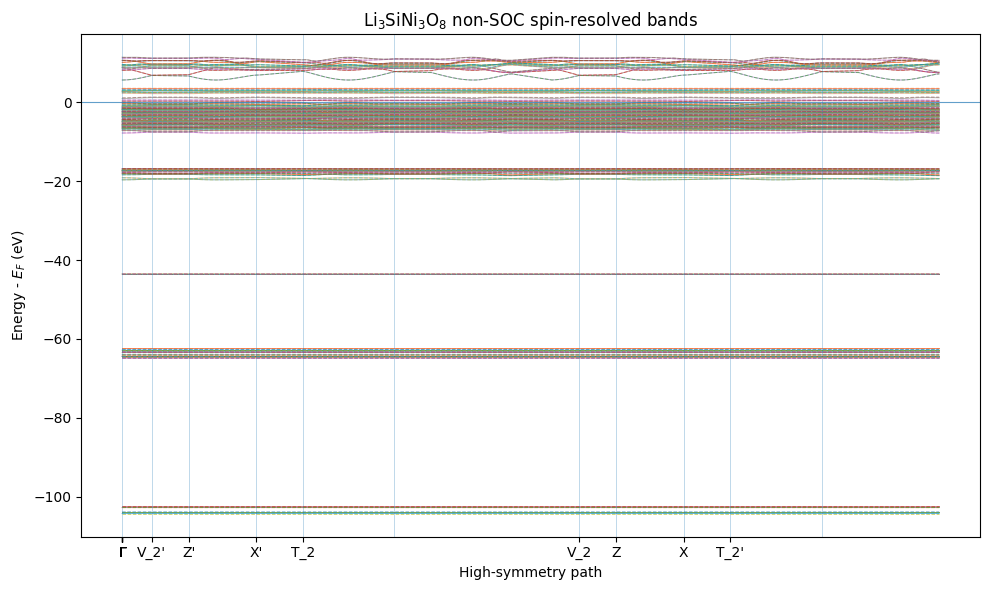


BAND PLOTTING COMPLETED
Spin-up bands   : (169, 138)
Spin-down bands : (169, 138)
K-points        : 169
Number of bands : 138
Fermi energy    : 7.8898 eV
High-symmetry points: 15
Saved           : Li3SiNi3O8_spin_resolved_bands.png


In [ ]:
# CELL 25 — PLOTTING: Parse, plot, and save the bands

%cd /content/Li3SiNi3O8_band_backup

import re
import json
import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Robust QE filband parser
# ============================================================
def parse_filband(path):
    with open(path, "r", errors="ignore") as f:
        txt = f.read()

    m = re.search(
        r"nbnd\s*=\s*(\d+)\s*,\s*nks\s*=\s*(\d+)",
        txt,
        re.IGNORECASE
    )

    if not m:
        raise ValueError(f"Could not find nbnd/nks header in {path}")

    nbnd = int(m.group(1))
    nks = int(m.group(2))

    body = txt[m.end():]

    # Explicit numeric-token parser.
    # This safely ignores the "/" after the QE header.
    float_pattern = re.compile(
        r"""
        [-+]?
        (?:
            (?:\d+\.\d*)
            |
            (?:\.\d+)
            |
            (?:\d+)
        )
        (?:
            [EeDd][-+]?\d+
        )?
        """,
        re.VERBOSE
    )

    tokens = float_pattern.findall(body)

    numbers = np.array(
        [float(x.replace("D", "E").replace("d", "e")) for x in tokens],
        dtype=float
    )

    expected = nks * (3 + nbnd)

    if numbers.size < expected:
        raise ValueError(
            f"{path}: expected {expected} numeric values, "
            f"found {numbers.size}"
        )

    block = numbers[:expected].reshape(nks, 3 + nbnd)

    return block[:, :3], block[:, 3:]


# ============================================================
# 2. Read spin channels
# ============================================================
spinup_file = "Li3SiNi3O8_spinup.dat"
spindown_file = "Li3SiNi3O8_spindown.dat"

if not os.path.exists(spinup_file):
    raise FileNotFoundError(spinup_file)

if not os.path.exists(spindown_file):
    raise FileNotFoundError(spindown_file)

ku, eu = parse_filband(spinup_file)
kd, ed = parse_filband(spindown_file)

print("Parsed spin-up   :", eu.shape)
print("Parsed spin-down :", ed.shape)

if ku.shape != kd.shape:
    raise ValueError(
        f"Spin-up/down k-point shapes differ: {ku.shape} vs {kd.shape}"
    )

if eu.shape != ed.shape:
    raise ValueError(
        f"Spin-up/down energy shapes differ: {eu.shape} vs {ed.shape}"
    )


# ============================================================
# 3. Fermi energy
# ============================================================
fermi = None

if os.path.exists("final_scf_2.out"):
    with open("final_scf_2.out", "r", errors="ignore") as f:
        t = f.read()

    mm = re.search(
        r"the Fermi energy is\s+"
        r"([-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[EeDd][-+]?\d+)?)"
        r"\s+ev",
        t,
        re.IGNORECASE
    )

    if mm:
        fermi = float(
            mm.group(1).replace("D", "E").replace("d", "e")
        )

print("Fermi energy     :", fermi, "eV")


# ============================================================
# 4. Cumulative k-path distance
# ============================================================
kdist = np.zeros(len(ku), dtype=float)

for i in range(1, len(ku)):
    kdist[i] = (
        kdist[i - 1]
        + np.linalg.norm(ku[i] - ku[i - 1])
    )


# ============================================================
# 5. Load path metadata
# ============================================================
with open("path_meta.json", "r") as f:
    meta_obj = json.load(f)

if "path" not in meta_obj:
    raise KeyError(
        "path_meta.json does not contain 'path'"
    )

path = meta_obj["path"]

if "point_coords" not in meta_obj:
    raise KeyError(
        "path_meta.json does not contain 'point_coords'"
    )

point_coords = {
    k: np.asarray(v, dtype=float)
    for k, v in meta_obj["point_coords"].items()
}


# ============================================================
# 6. Determine high-symmetry k-point indices
#
# Supports:
#   A) old path_meta.json with "meta"
#   B) current path_meta.json without "meta"
# ============================================================
xticks = []
xlabels = []
boundaries = []


if "meta" in meta_obj and meta_obj["meta"]:
    # --------------------------------------------------------
    # Original metadata format
    # --------------------------------------------------------
    meta = meta_obj["meta"]

    for seg_i, (a, b) in enumerate(path):

        inds = [
            j for j, m in enumerate(meta)
            if m["segment"] == seg_i
        ]

        if not inds:
            raise ValueError(
                f"No metadata for path segment {seg_i}: {a} -> {b}"
            )

        idx0 = inds[0]
        idx1 = inds[-1]

        boundaries.extend([idx0, idx1])

        if seg_i == 0:
            xticks.append(kdist[idx0])
            xlabels.append(
                "Γ" if a.upper() == "GAMMA" else a
            )

        xticks.append(kdist[idx1])
        xlabels.append(
            "Γ" if b.upper() == "GAMMA" else b
        )

else:
    # --------------------------------------------------------
    # Current metadata format:
    # use point_coords + actual k-points from filband
    # --------------------------------------------------------

    print("No 'meta' entry found; deriving high-symmetry points from point_coords.")

    # Find the closest actual k-point to each requested
    # high-symmetry coordinate.
    def find_kindex(target, used=None):
        target = np.asarray(target, dtype=float)

        distances = np.linalg.norm(
            ku - target[None, :],
            axis=1
        )

        if used:
            distances[list(used)] = np.inf

        idx = int(np.argmin(distances))

        return idx, float(distances[idx])

    used_indices = set()

    # Collect all segment endpoints in path order.
    endpoints = []

    for seg_i, (a, b) in enumerate(path):

        if a not in point_coords:
            raise KeyError(
                f"High-symmetry point '{a}' missing from point_coords"
            )

        if b not in point_coords:
            raise KeyError(
                f"High-symmetry point '{b}' missing from point_coords"
            )

        endpoints.append((seg_i, a, point_coords[a], "start"))
        endpoints.append((seg_i, b, point_coords[b], "end"))

    # We map every endpoint to an actual k-point.
    endpoint_indices = []

    for seg_i, label, coord, role in endpoints:

        idx, dist = find_kindex(coord)

        # Numerical differences should be tiny.
        if dist > 1e-6:
            print(
                f"⚠️ {label}: nearest k-point distance = {dist:.3e}"
            )

        endpoint_indices.append(
            (seg_i, label, role, idx, dist)
        )

    # --------------------------------------------------------
    # Construct ticks from segment starts/ends.
    # Avoid duplicate ticks at shared endpoints.
    # --------------------------------------------------------
    for seg_i, (a, b) in enumerate(path):

        start_candidates = [
            x for x in endpoint_indices
            if x[0] == seg_i and x[1] == a and x[2] == "start"
        ]

        end_candidates = [
            x for x in endpoint_indices
            if x[0] == seg_i and x[1] == b and x[2] == "end"
        ]

        idx0 = start_candidates[0][3]
        idx1 = end_candidates[0][3]

        boundaries.extend([idx0, idx1])

        if seg_i == 0:
            xticks.append(kdist[idx0])
            xlabels.append(
                "Γ" if a.upper() == "GAMMA" else a
            )

        xticks.append(kdist[idx1])
        xlabels.append(
            "Γ" if b.upper() == "GAMMA" else b
        )


# ============================================================
# 7. Remove duplicate x-axis labels at identical positions
# ============================================================
clean_xticks = []
clean_xlabels = []

for x, label in zip(xticks, xlabels):

    if not clean_xticks:
        clean_xticks.append(x)
        clean_xlabels.append(label)

    elif not np.isclose(x, clean_xticks[-1], atol=1e-10):
        clean_xticks.append(x)
        clean_xlabels.append(label)

    else:
        # Shared path endpoint:
        # keep the label from the latest segment.
        clean_xlabels[-1] = label

xticks = clean_xticks
xlabels = clean_xlabels


# ============================================================
# 8. Plot spin-resolved bands
# ============================================================
plt.figure(figsize=(10, 6))

shift = fermi if fermi is not None else 0.0

# Spin-up
for band in eu.T:
    plt.plot(
        kdist,
        band - shift,
        linewidth=0.7,
        alpha=0.6
    )

# Spin-down
for band in ed.T:
    plt.plot(
        kdist,
        band - shift,
        linestyle="--",
        linewidth=0.7,
        alpha=0.6
    )


# High-symmetry boundaries
for i in sorted(set(boundaries)):
    plt.axvline(
        kdist[i],
        linewidth=0.5,
        alpha=0.4
    )

# Fermi level
plt.axhline(
    0.0,
    linewidth=0.8,
    alpha=0.7
)

plt.xticks(
    xticks,
    xlabels
)

plt.ylabel(r"Energy - $E_F$ (eV)")
plt.xlabel("High-symmetry path")
plt.title(
    r"Li$_3$SiNi$_3$O$_8$ non-SOC spin-resolved bands"
)

plt.tight_layout()

output_png = "Li3SiNi3O8_spin_resolved_bands.png"

plt.savefig(
    output_png,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. Final verification
# ============================================================
print()
print("=" * 60)
print("BAND PLOTTING COMPLETED")
print("=" * 60)
print("Spin-up bands   :", eu.shape)
print("Spin-down bands :", ed.shape)
print("K-points        :", len(ku))
print("Number of bands :", eu.shape[1])
print("Fermi energy    :", fermi, "eV")
print("High-symmetry points:", len(xticks))
print("Saved           :", output_png)
print("=" * 60)

/content/Li3SiNi3O8_band_backup
Spin-up bands   : (169, 138)
Spin-down bands : (169, 138)
Fermi energy    : 7.8898 eV

Near-EF band indices:
[86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121]
Number of plotted bands: 36


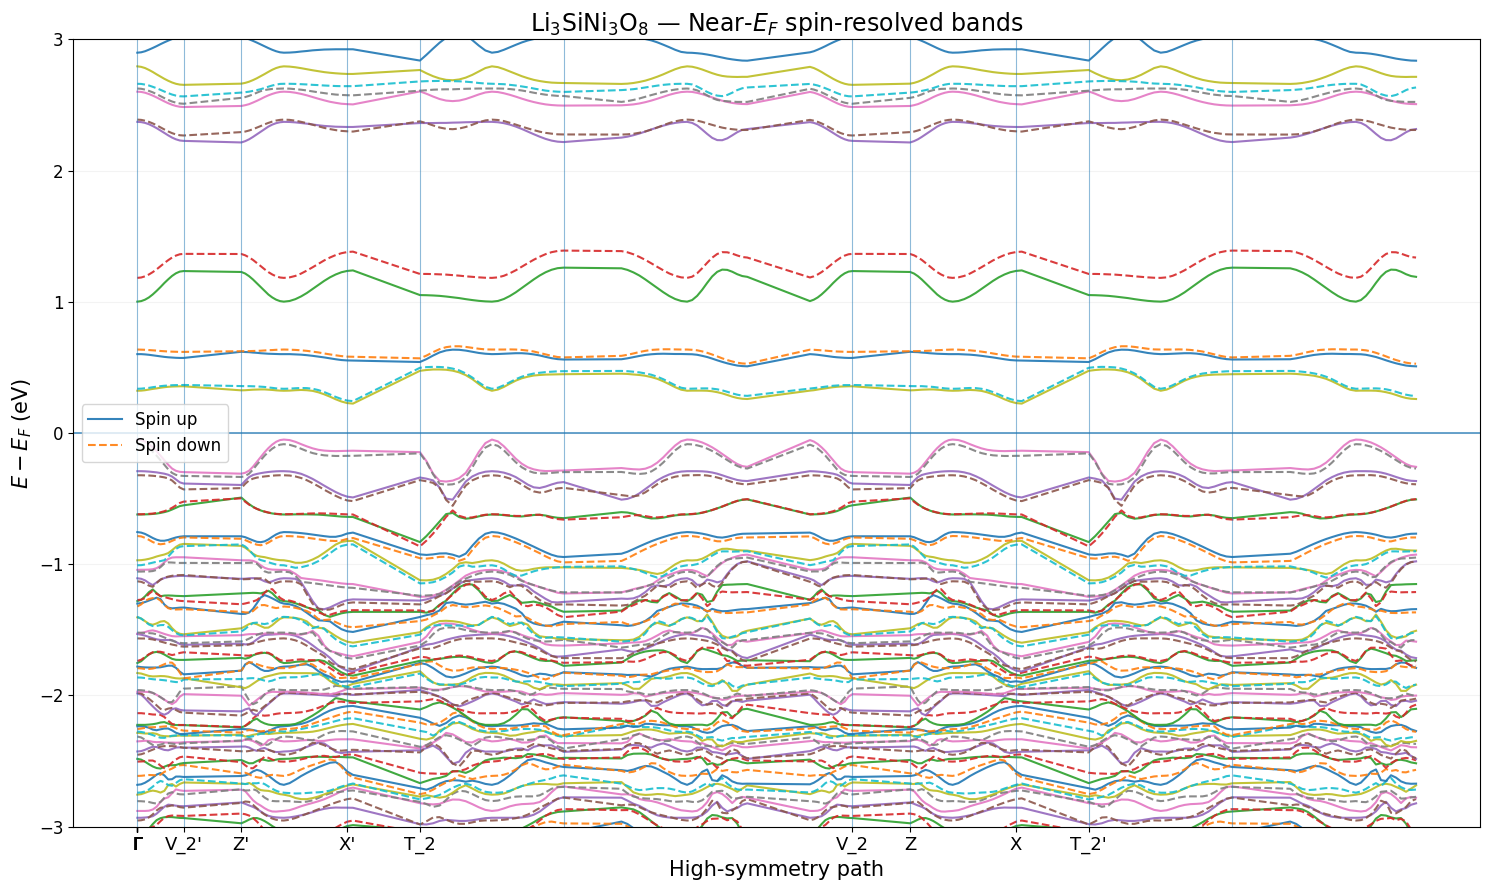

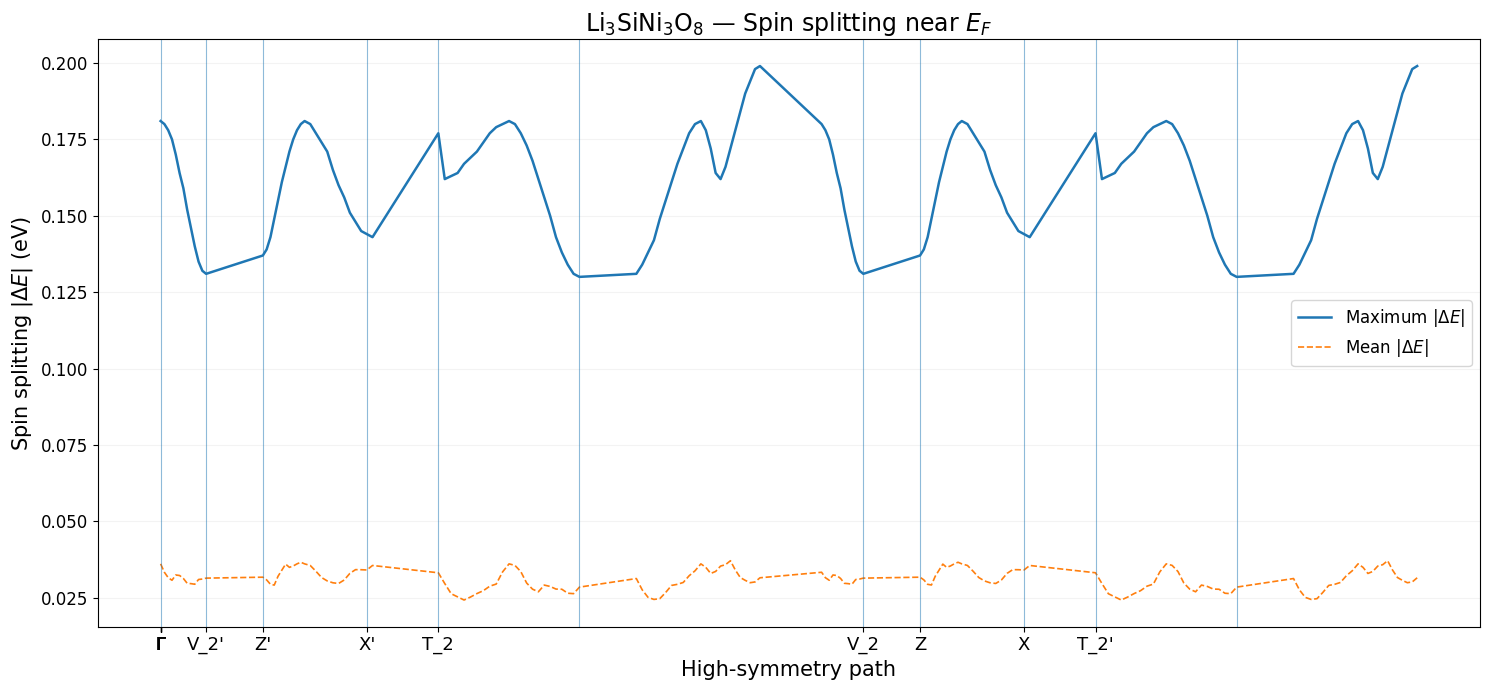


HIGH-RESOLUTION BAND ANALYSIS
Fermi energy              : 7.889800 eV
EF window                 : -3.0 to +3.0 eV
Near-EF bands plotted     : 36
Maximum spin splitting    : 0.199000 eV
Maximum splitting k-index : 84
Maximum splitting k-dist  : 4.745169

Saved files:
   Li3SiNi3O8_near_EF_spin_resolved_bands.png
   Li3SiNi3O8_spin_splitting.png


In [ ]:
# CELL 25b — PLOTTING: High-resolution near-Fermi spin splitting

%cd /content/Li3SiNi3O8_band_backup

import re
import json
import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Robust QE filband parser
# ============================================================
def parse_filband(path):

    with open(path, "r", errors="ignore") as f:
        txt = f.read()

    m = re.search(
        r"nbnd\s*=\s*(\d+)\s*,\s*nks\s*=\s*(\d+)",
        txt,
        re.IGNORECASE
    )

    if not m:
        raise ValueError(f"Could not find nbnd/nks in {path}")

    nbnd = int(m.group(1))
    nks = int(m.group(2))

    body = txt[m.end():]

    float_pattern = re.compile(
        r"""
        [-+]?
        (?:
            (?:\d+\.\d*)
            |
            (?:\.\d+)
            |
            (?:\d+)
        )
        (?:
            [EeDd][-+]?\d+
        )?
        """,
        re.VERBOSE
    )

    tokens = float_pattern.findall(body)

    numbers = np.array(
        [float(x.replace("D", "E").replace("d", "e"))
         for x in tokens],
        dtype=float
    )

    expected = nks * (3 + nbnd)

    if numbers.size < expected:
        raise ValueError(
            f"{path}: expected {expected} values, found {numbers.size}"
        )

    block = numbers[:expected].reshape(nks, 3 + nbnd)

    return block[:, :3], block[:, 3:]


# ============================================================
# 2. Read spin-up / spin-down
# ============================================================
ku, eu = parse_filband("Li3SiNi3O8_spinup.dat")
kd, ed = parse_filband("Li3SiNi3O8_spindown.dat")

if ku.shape != kd.shape:
    raise ValueError(f"k-point shapes differ: {ku.shape} vs {kd.shape}")

if eu.shape != ed.shape:
    raise ValueError(f"band shapes differ: {eu.shape} vs {ed.shape}")

print("Spin-up bands   :", eu.shape)
print("Spin-down bands :", ed.shape)


# ============================================================
# 3. Fermi energy
# ============================================================
fermi = None

if os.path.exists("final_scf_2.out"):

    with open("final_scf_2.out", "r", errors="ignore") as f:
        scf_txt = f.read()

    mm = re.search(
        r"the Fermi energy is\s+"
        r"([-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[EeDd][-+]?\d+)?)"
        r"\s+ev",
        scf_txt,
        re.IGNORECASE
    )

    if mm:
        fermi = float(
            mm.group(1).replace("D", "E").replace("d", "e")
        )

if fermi is None:
    raise ValueError("Fermi energy could not be found.")

print("Fermi energy    :", fermi, "eV")


# ============================================================
# 4. Convert energies to E - EF
# ============================================================
eu_rel = eu - fermi
ed_rel = ed - fermi


# ============================================================
# 5. k-path distance
# ============================================================
kdist = np.zeros(len(ku))

for i in range(1, len(ku)):
    kdist[i] = (
        kdist[i - 1]
        + np.linalg.norm(ku[i] - ku[i - 1])
    )


# ============================================================
# 6. High-symmetry points
# ============================================================
with open("path_meta.json", "r") as f:
    meta_obj = json.load(f)

path = meta_obj["path"]

point_coords = {
    k: np.asarray(v, dtype=float)
    for k, v in meta_obj["point_coords"].items()
}


def nearest_kpoint_index(target):

    target = np.asarray(target, dtype=float)

    d = np.linalg.norm(
        ku - target[None, :],
        axis=1
    )

    return int(np.argmin(d))


xticks = []
xlabels = []
boundaries = []

for seg_i, (a, b) in enumerate(path):

    idx_a = nearest_kpoint_index(point_coords[a])
    idx_b = nearest_kpoint_index(point_coords[b])

    boundaries.extend([idx_a, idx_b])

    if seg_i == 0:
        xticks.append(kdist[idx_a])
        xlabels.append("Γ" if a.upper() == "GAMMA" else a)

    xticks.append(kdist[idx_b])
    xlabels.append("Γ" if b.upper() == "GAMMA" else b)


# Remove duplicate ticks
clean_x = []
clean_labels = []

for x, label in zip(xticks, xlabels):

    if not clean_x or not np.isclose(x, clean_x[-1]):
        clean_x.append(x)
        clean_labels.append(label)
    else:
        clean_labels[-1] = label

xticks = clean_x
xlabels = clean_labels


# ============================================================
# 7. Select ONLY bands close to Fermi level
#
# This removes the deep core states that made the previous
# figure unreadable.
# ============================================================
WINDOW_BELOW = 3.0     # eV below EF
WINDOW_ABOVE = 3.0     # eV above EF

combined = np.concatenate([eu_rel, ed_rel], axis=0)

band_min = np.min(combined, axis=0)
band_max = np.max(combined, axis=0)

selected = np.where(
    (band_max >= -WINDOW_BELOW) &
    (band_min <= WINDOW_ABOVE)
)[0]

if len(selected) == 0:
    raise ValueError("No bands found inside the selected EF window.")

print()
print("Near-EF band indices:")
print(selected.tolist())
print("Number of plotted bands:", len(selected))


# ============================================================
# 8. HIGH-RESOLUTION BAND STRUCTURE
# ============================================================
fig = plt.figure(figsize=(15, 9))

for ib in selected:

    plt.plot(
        kdist,
        eu_rel[:, ib],
        linewidth=1.5,
        alpha=0.9,
        label="Spin up" if ib == selected[0] else None
    )

    plt.plot(
        kdist,
        ed_rel[:, ib],
        linestyle="--",
        linewidth=1.5,
        alpha=0.9,
        label="Spin down" if ib == selected[0] else None
    )


# High-symmetry vertical lines
for idx in sorted(set(boundaries)):
    plt.axvline(
        kdist[idx],
        linewidth=0.8,
        alpha=0.5
    )


# Fermi level
plt.axhline(
    0.0,
    linewidth=1.2,
    alpha=0.8
)


plt.xticks(
    xticks,
    xlabels,
    fontsize=13
)

plt.yticks(fontsize=12)

plt.ylabel(
    r"$E-E_F$ (eV)",
    fontsize=15
)

plt.xlabel(
    "High-symmetry path",
    fontsize=15
)

plt.title(
    r"Li$_3$SiNi$_3$O$_8$ — Near-$E_F$ spin-resolved bands",
    fontsize=17
)

plt.ylim(
    -WINDOW_BELOW,
    WINDOW_ABOVE
)

plt.grid(
    axis="y",
    alpha=0.15
)

plt.legend(
    fontsize=12,
    loc="best"
)

plt.tight_layout()

band_png = "Li3SiNi3O8_near_EF_spin_resolved_bands.png"

plt.savefig(
    band_png,
    dpi=400,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. CALCULATE SPIN SPLITTING
#
# For corresponding spin-up/down bands:
#
#   Delta E(k) = |E_up(k) - E_down(k)|
#
# Only near-EF bands are considered.
# ============================================================
splitting = np.abs(
    eu_rel[:, selected] -
    ed_rel[:, selected]
)

max_splitting = np.max(
    splitting,
    axis=1
)

mean_splitting = np.mean(
    splitting,
    axis=1
)


# ============================================================
# 10. SPLITTING VS k-PATH
# ============================================================
plt.figure(figsize=(15, 7))

plt.plot(
    kdist,
    max_splitting,
    linewidth=1.8,
    label=r"Maximum $|\Delta E|$"
)

plt.plot(
    kdist,
    mean_splitting,
    linewidth=1.2,
    linestyle="--",
    label=r"Mean $|\Delta E|$"
)

for idx in sorted(set(boundaries)):
    plt.axvline(
        kdist[idx],
        linewidth=0.8,
        alpha=0.5
    )

plt.xticks(
    xticks,
    xlabels,
    fontsize=13
)

plt.yticks(fontsize=12)

plt.ylabel(
    r"Spin splitting $|\Delta E|$ (eV)",
    fontsize=15
)

plt.xlabel(
    "High-symmetry path",
    fontsize=15
)

plt.title(
    r"Li$_3$SiNi$_3$O$_8$ — Spin splitting near $E_F$",
    fontsize=17
)

plt.grid(
    axis="y",
    alpha=0.15
)

plt.legend(
    fontsize=12
)

plt.tight_layout()

split_png = "Li3SiNi3O8_spin_splitting.png"

plt.savefig(
    split_png,
    dpi=400,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. Numerical splitting information
# ============================================================
imax = int(np.argmax(max_splitting))

print()
print("=" * 70)
print("HIGH-RESOLUTION BAND ANALYSIS")
print("=" * 70)

print(f"Fermi energy              : {fermi:.6f} eV")
print(f"EF window                 : -{WINDOW_BELOW:.1f} to +{WINDOW_ABOVE:.1f} eV")
print(f"Near-EF bands plotted     : {len(selected)}")
print(f"Maximum spin splitting    : {max_splitting[imax]:.6f} eV")
print(f"Maximum splitting k-index : {imax}")
print(f"Maximum splitting k-dist  : {kdist[imax]:.6f}")

print()
print("Saved files:")
print("  ", band_png)
print("  ", split_png)

print("=" * 70)

/content/Li3SiNi3O8_band_backup
Spin-up   : (169, 138)
Spin-down : (169, 138)
Fermi energy = 7.889800 eV

Energy window = -1.5 to 1.5 eV
Selected bands = [104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117]
Number selected = 14


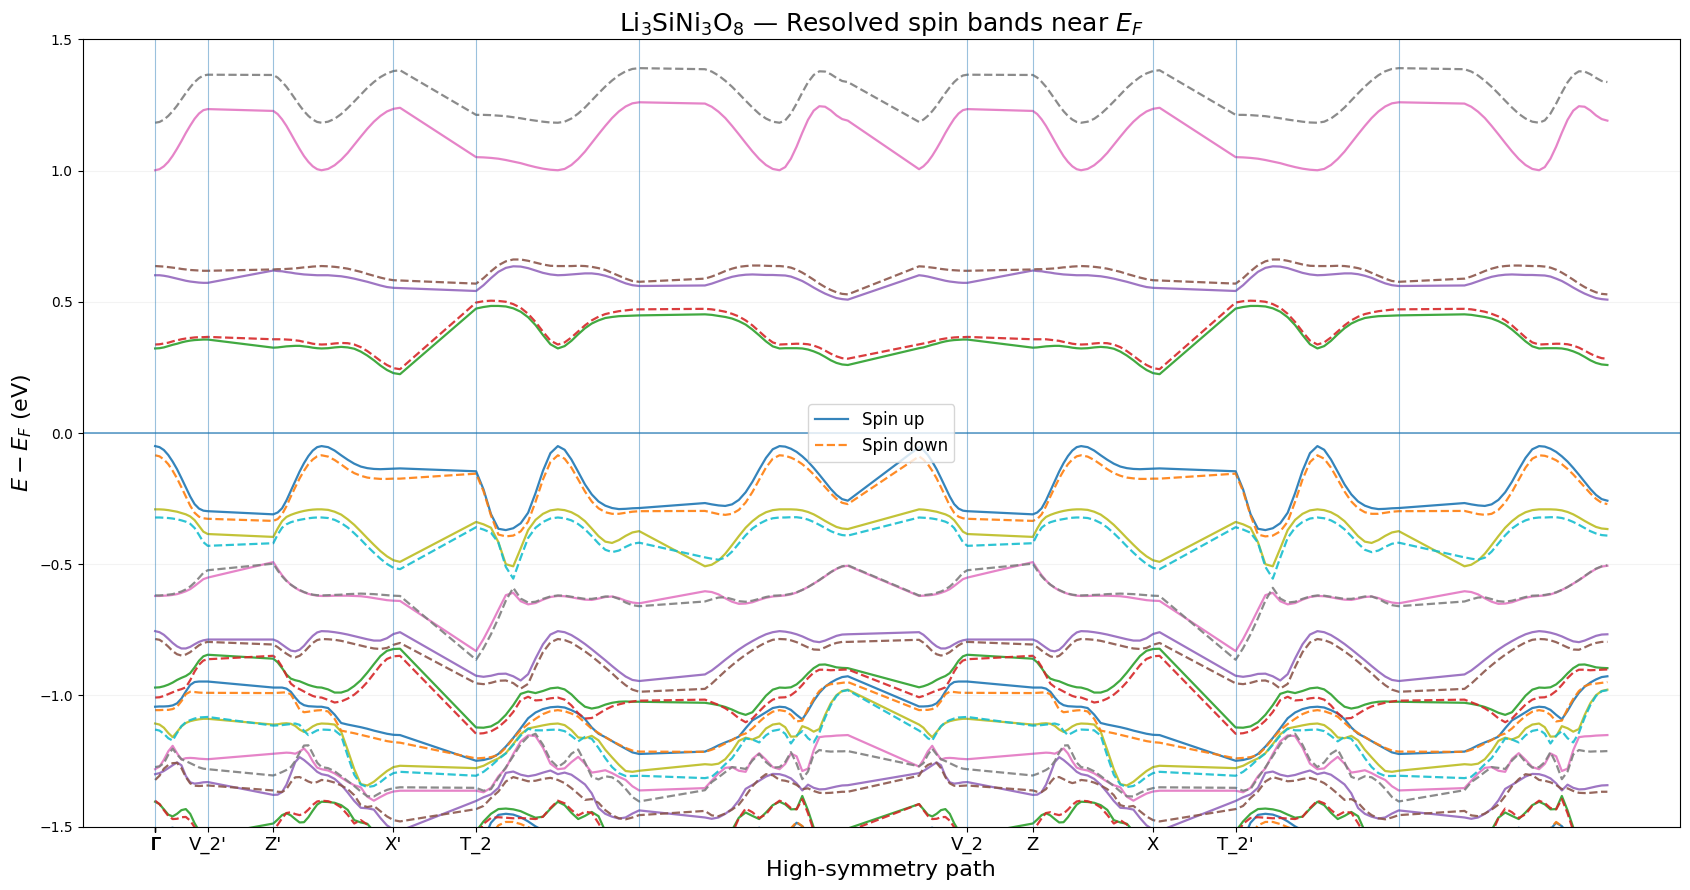

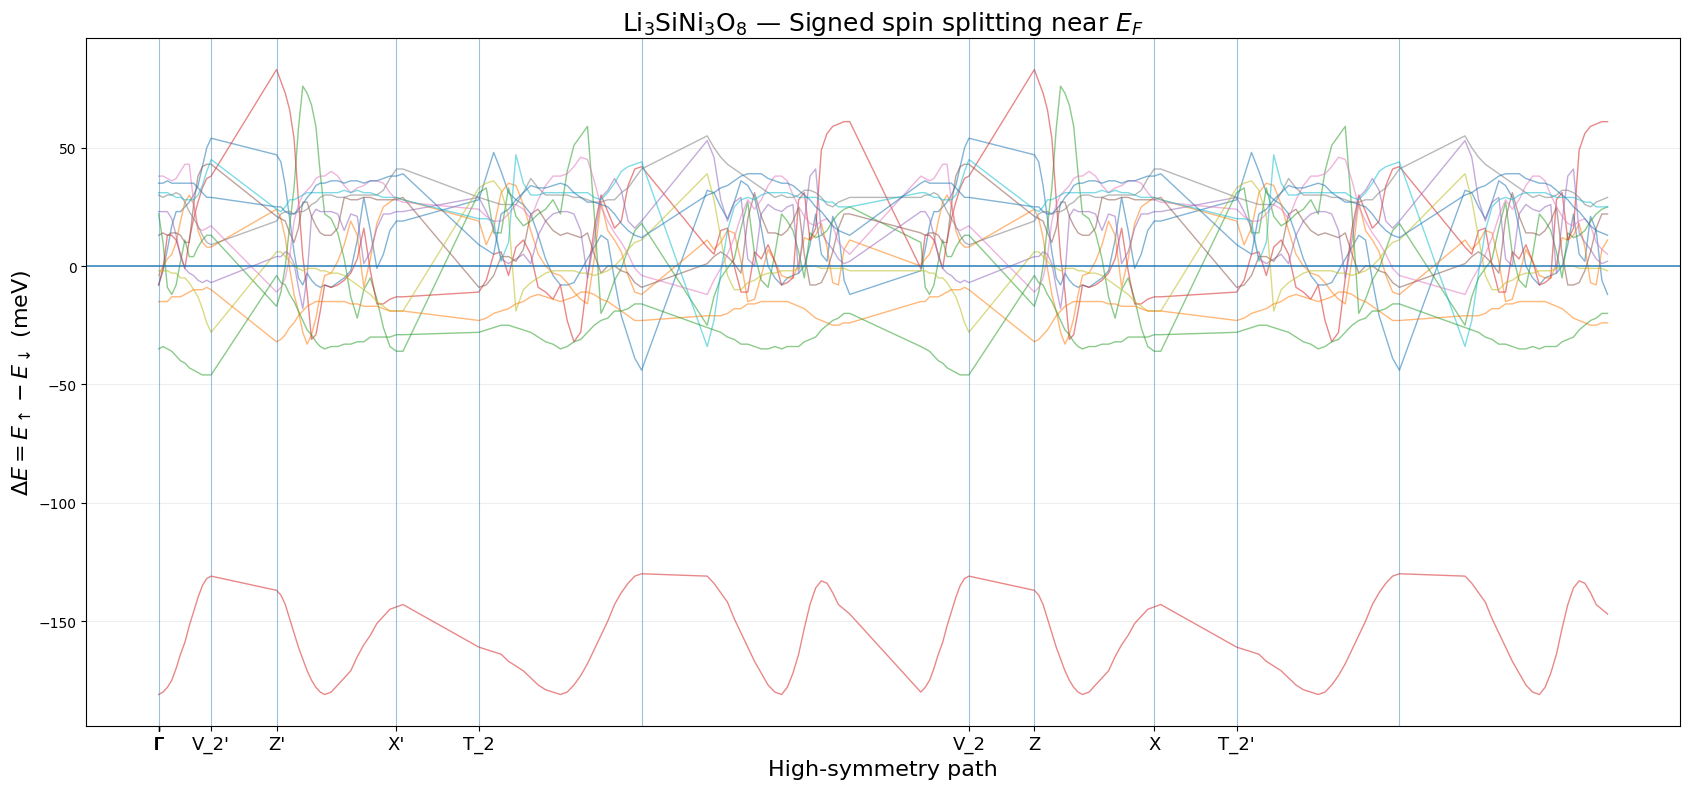

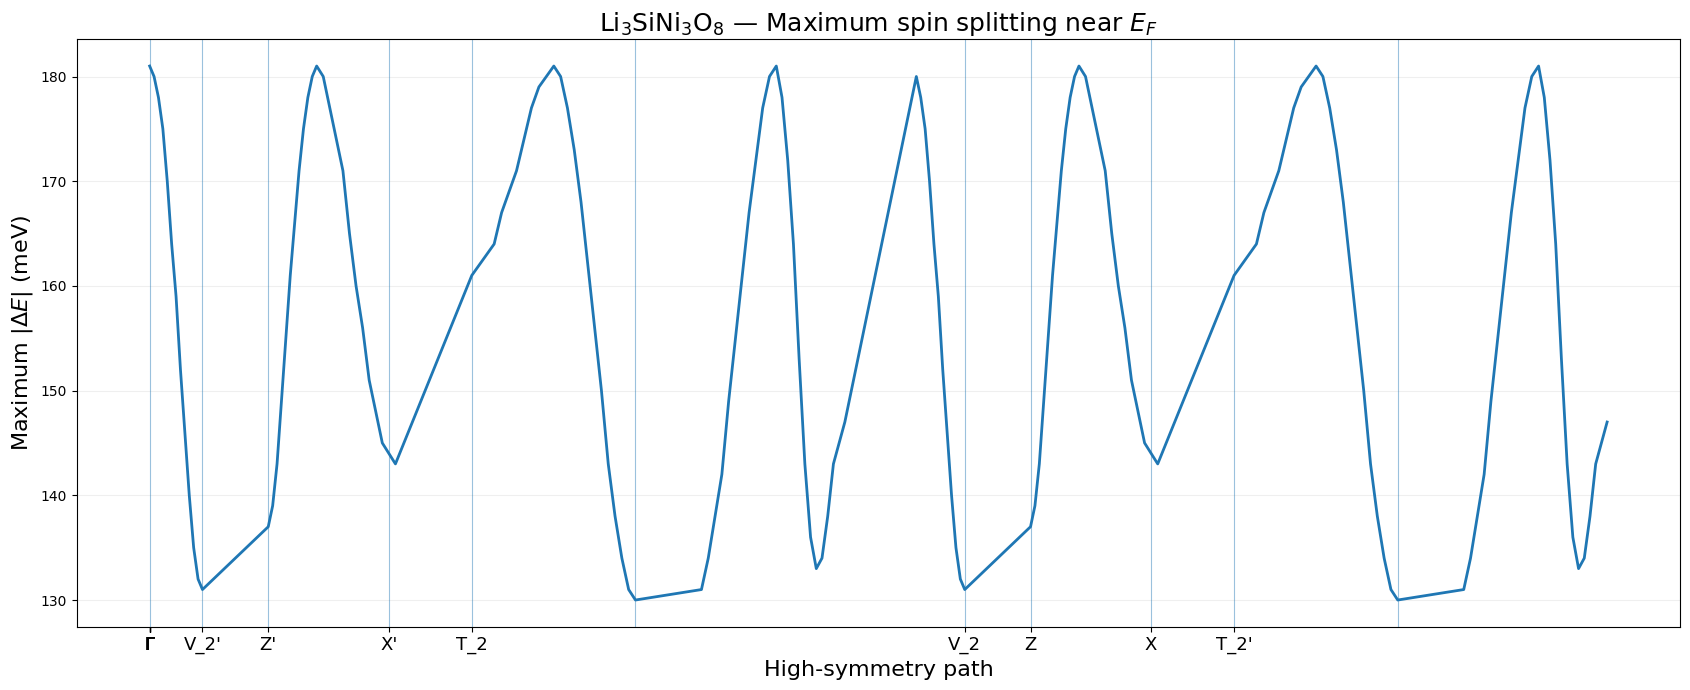


STRONGEST SPIN-SPLITTING LOCATIONS
k-index=  0   k-distance=  0.000000   band=117   ΔE=  -181.000 meV
k-index=156   k-distance=  9.480325   band=117   ΔE=  -181.000 meV
k-index=132   k-distance=  7.961750   band=117   ΔE=  -181.000 meV
k-index= 48   k-distance=  2.758699   band=117   ΔE=  -181.000 meV
k-index=108   k-distance=  6.343054   band=117   ΔE=  -181.000 meV
k-index= 72   k-distance=  4.277274   band=117   ΔE=  -181.000 meV
k-index= 24   k-distance=  1.140002   band=117   ΔE=  -181.000 meV
k-index=107   k-distance=  6.313009   band=117   ΔE=  -180.000 meV
k-index= 85   k-distance=  5.233095   band=117   ΔE=  -180.000 meV
k-index=155   k-distance=  9.433882   band=117   ΔE=  -180.000 meV
k-index=133   k-distance=  8.008193   band=117   ΔE=  -180.000 meV
k-index= 23   k-distance=  1.109958   band=117   ΔE=  -180.000 meV
k-index= 25   k-distance=  1.184807   band=117   ΔE=  -180.000 meV
k-index= 49   k-distance=  2.805142   band=117   ΔE=  -180.000 meV
k-index=109   k-distance= 

In [ ]:
# CELL 25c — ALTERMAGNETIC SPLITTING DIAGNOSTIC
#
# Purpose:
#   1. Resolve spin-up/down bands near EF
#   2. Calculate signed ΔE = E_up - E_down
#   3. Display ΔE in meV
#   4. Identify k-points with the largest splitting
#
# IMPORTANT:
#   The signed ΔE plot is more informative for altermagnetism
#   than plotting |ΔE| because the sign is retained.


%cd /content/Li3SiNi3O8_band_backup

import re
import json
import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. QE filband parser
# ============================================================
def parse_filband(path):

    with open(path, "r", errors="ignore") as f:
        txt = f.read()

    m = re.search(
        r"nbnd\s*=\s*(\d+)\s*,\s*nks\s*=\s*(\d+)",
        txt,
        re.IGNORECASE
    )

    if not m:
        raise ValueError(f"Could not find nbnd/nks in {path}")

    nbnd = int(m.group(1))
    nks = int(m.group(2))

    body = txt[m.end():]

    pattern = re.compile(
        r"""
        [-+]?
        (?:
            \d+\.\d*
            |
            \.\d+
            |
            \d+
        )
        (?:
            [EeDd][-+]?\d+
        )?
        """,
        re.VERBOSE
    )

    tokens = pattern.findall(body)

    numbers = np.array(
        [
            float(x.replace("D", "E").replace("d", "e"))
            for x in tokens
        ],
        dtype=float
    )

    expected = nks * (3 + nbnd)

    if numbers.size < expected:
        raise ValueError(
            f"{path}: expected {expected} values, found {numbers.size}"
        )

    block = numbers[:expected].reshape(
        nks,
        3 + nbnd
    )

    return block[:, :3], block[:, 3:]


# ============================================================
# 2. Read spin-resolved bands
# ============================================================
ku, eu = parse_filband(
    "Li3SiNi3O8_spinup.dat"
)

kd, ed = parse_filband(
    "Li3SiNi3O8_spindown.dat"
)

if eu.shape != ed.shape:
    raise ValueError(
        f"Spin channel shapes differ: {eu.shape} vs {ed.shape}"
    )

print("Spin-up   :", eu.shape)
print("Spin-down :", ed.shape)


# ============================================================
# 3. Fermi energy
# ============================================================
fermi = None

if os.path.exists("final_scf_2.out"):

    with open(
        "final_scf_2.out",
        "r",
        errors="ignore"
    ) as f:
        txt = f.read()

    m = re.search(
        r"the Fermi energy is\s+"
        r"([-+]?(?:\d+(?:\.\d*)?|\.\d+)"
        r"(?:[EeDd][-+]?\d+)?)"
        r"\s+ev",
        txt,
        re.IGNORECASE
    )

    if m:
        fermi = float(
            m.group(1)
            .replace("D", "E")
            .replace("d", "e")
        )

if fermi is None:
    raise ValueError(
        "Fermi energy not found."
    )

print(f"Fermi energy = {fermi:.6f} eV")


# ============================================================
# 4. Energies relative to EF
# ============================================================
eu_rel = eu - fermi
ed_rel = ed - fermi


# ============================================================
# 5. k-path distance
# ============================================================
kdist = np.zeros(len(ku))

for i in range(1, len(ku)):

    kdist[i] = (
        kdist[i - 1]
        + np.linalg.norm(
            ku[i] - ku[i - 1]
        )
    )


# ============================================================
# 6. Read high-symmetry path
# ============================================================
with open("path_meta.json", "r") as f:
    path_obj = json.load(f)

path = path_obj["path"]

point_coords = {
    key: np.asarray(value, dtype=float)
    for key, value in path_obj["point_coords"].items()
}


def nearest_kpoint(coord):

    coord = np.asarray(
        coord,
        dtype=float
    )

    distance = np.linalg.norm(
        ku - coord[None, :],
        axis=1
    )

    return int(
        np.argmin(distance)
    )


xticks = []
xlabels = []
boundary_indices = []

for seg_i, (a, b) in enumerate(path):

    ia = nearest_kpoint(
        point_coords[a]
    )

    ib = nearest_kpoint(
        point_coords[b]
    )

    boundary_indices.extend(
        [ia, ib]
    )

    if seg_i == 0:

        xticks.append(
            kdist[ia]
        )

        xlabels.append(
            "Γ"
            if a.upper() == "GAMMA"
            else a
        )

    xticks.append(
        kdist[ib]
    )

    xlabels.append(
        "Γ"
        if b.upper() == "GAMMA"
        else b
    )


# Remove duplicate labels
new_xticks = []
new_labels = []

for x, label in zip(
    xticks,
    xlabels
):

    if (
        len(new_xticks) == 0
        or not np.isclose(
            x,
            new_xticks[-1],
            atol=1e-10
        )
    ):
        new_xticks.append(x)
        new_labels.append(label)
    else:
        new_labels[-1] = label

xticks = new_xticks
xlabels = new_labels


# ============================================================
# 7. Choose the energy region of interest
#
# Adjust these two numbers to inspect another region.
# ============================================================
LOWER_E = -1.5
UPPER_E =  1.5


# Select a band if it enters this energy window
band_low = np.minimum(
    eu_rel.min(axis=0),
    ed_rel.min(axis=0)
)

band_high = np.maximum(
    eu_rel.max(axis=0),
    ed_rel.max(axis=0)
)

selected = np.where(
    (band_high >= LOWER_E)
    &
    (band_low <= UPPER_E)
)[0]


print()
print(
    f"Energy window = "
    f"{LOWER_E} to {UPPER_E} eV"
)

print(
    "Selected bands =",
    selected.tolist()
)

print(
    "Number selected =",
    len(selected)
)


# ============================================================
# 8. SIGNED SPIN SPLITTING
#
# ΔE = E_up - E_down
#
# Positive:
#   spin-up lies above spin-down
#
# Negative:
#   spin-up lies below spin-down
# ============================================================
deltaE = eu_rel - ed_rel

delta_selected = deltaE[:, selected]


# ============================================================
# 9. HIGH-RESOLUTION NEAR-EF BAND STRUCTURE
# ============================================================
plt.figure(
    figsize=(17, 9)
)

for n, band_index in enumerate(selected):

    plt.plot(
        kdist,
        eu_rel[:, band_index],
        linewidth=1.6,
        alpha=0.9,
        label="Spin up"
        if n == 0
        else None
    )

    plt.plot(
        kdist,
        ed_rel[:, band_index],
        linestyle="--",
        linewidth=1.6,
        alpha=0.9,
        label="Spin down"
        if n == 0
        else None
    )


for idx in sorted(
    set(boundary_indices)
):

    plt.axvline(
        kdist[idx],
        linewidth=0.8,
        alpha=0.45
    )


plt.axhline(
    0,
    linewidth=1.1,
    alpha=0.8
)

plt.xticks(
    xticks,
    xlabels,
    fontsize=13
)

plt.ylabel(
    r"$E-E_F$ (eV)",
    fontsize=16
)

plt.xlabel(
    "High-symmetry path",
    fontsize=16
)

plt.title(
    r"Li$_3$SiNi$_3$O$_8$ — Resolved spin bands near $E_F$",
    fontsize=18
)

plt.ylim(
    LOWER_E,
    UPPER_E
)

plt.grid(
    axis="y",
    alpha=0.15
)

plt.legend(
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "Li3SiNi3O8_near_EF_high_resolution.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. SIGNED ΔE PLOT — MAIN ALTERMAGNETISM DIAGNOSTIC
# ============================================================
plt.figure(
    figsize=(17, 8)
)

# Plot every selected band's signed splitting
for n in range(len(selected)):

    plt.plot(
        kdist,
        delta_selected[:, n] * 1000.0,
        linewidth=1.0,
        alpha=0.55
    )


# Zero splitting reference
plt.axhline(
    0,
    linewidth=1.3,
    alpha=0.8
)


for idx in sorted(
    set(boundary_indices)
):

    plt.axvline(
        kdist[idx],
        linewidth=0.8,
        alpha=0.45
    )


plt.xticks(
    xticks,
    xlabels,
    fontsize=13
)

plt.ylabel(
    r"$\Delta E = E_{\uparrow}-E_{\downarrow}$ (meV)",
    fontsize=16
)

plt.xlabel(
    "High-symmetry path",
    fontsize=16
)

plt.title(
    r"Li$_3$SiNi$_3$O$_8$ — Signed spin splitting near $E_F$",
    fontsize=18
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "Li3SiNi3O8_signed_spin_splitting.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. MAXIMUM ABSOLUTE SPLITTING AT EACH k-POINT
# ============================================================
max_abs_split = np.max(
    np.abs(delta_selected),
    axis=1
)

plt.figure(
    figsize=(17, 7)
)

plt.plot(
    kdist,
    max_abs_split * 1000.0,
    linewidth=2.0
)

for idx in sorted(
    set(boundary_indices)
):

    plt.axvline(
        kdist[idx],
        linewidth=0.8,
        alpha=0.45
    )


plt.xticks(
    xticks,
    xlabels,
    fontsize=13
)

plt.ylabel(
    r"Maximum $|\Delta E|$ (meV)",
    fontsize=16
)

plt.xlabel(
    "High-symmetry path",
    fontsize=16
)

plt.title(
    r"Li$_3$SiNi$_3$O$_8$ — Maximum spin splitting near $E_F$",
    fontsize=18
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "Li3SiNi3O8_max_spin_splitting.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. FIND STRONGEST SPLITTING LOCATIONS
# ============================================================
flat_index = np.argsort(
    np.abs(delta_selected).ravel()
)[::-1]


print()
print("=" * 75)
print("STRONGEST SPIN-SPLITTING LOCATIONS")
print("=" * 75)

reported = 0
already = set()

for flat in flat_index:

    k_idx, band_local = np.unravel_index(
        flat,
        delta_selected.shape
    )

    band_global = selected[band_local]

    # Avoid reporting the same k/band repeatedly
    key = (
        k_idx,
        band_global
    )

    if key in already:
        continue

    already.add(key)

    d_mev = (
        delta_selected[
            k_idx,
            band_local
        ]
        * 1000.0
    )

    print(
        f"k-index={k_idx:3d}   "
        f"k-distance={kdist[k_idx]:10.6f}   "
        f"band={band_global:3d}   "
        f"ΔE={d_mev:+10.3f} meV"
    )

    reported += 1

    if reported >= 20:
        break


# ============================================================
# 13. GLOBAL MAXIMUM
# ============================================================
imax = np.unravel_index(
    np.argmax(
        np.abs(delta_selected)
    ),
    delta_selected.shape
)

kmax = imax[0]
bmax = selected[imax[1]]

print()
print("=" * 75)
print("GLOBAL MAXIMUM")
print("=" * 75)

print(
    f"k-index       = {kmax}"
)

print(
    f"k-distance    = {kdist[kmax]:.8f}"
)

print(
    f"band index    = {bmax}"
)

print(
    f"Delta E       = "
    f"{deltaE[kmax, bmax] * 1000.0:+.4f} meV"
)

print(
    f"|Delta E|     = "
    f"{abs(deltaE[kmax, bmax]) * 1000.0:.4f} meV"
)

print()
print("Saved:")
print("  Li3SiNi3O8_near_EF_high_resolution.png")
print("  Li3SiNi3O8_signed_spin_splitting.png")
print("  Li3SiNi3O8_max_spin_splitting.png")

print("=" * 75)

> **CELL 26 — OUTPUT: Final result files**

## 6. Final files to download

The useful outputs are:

- `bands.in`
- `bands.out`
- `bands_process_status.txt`
- `bands_up.out`
- `bands_down.out`
- `Li3SiNi3O8_spinup.dat`
- `Li3SiNi3O8_spindown.dat`
- `Li3SiNi3O8_spin_resolved_bands.png`
- `seekpath_report.txt`
- `path_meta.json`

For later analysis, keep the original `Li3SiNi3O8_band_backup/` directory as well.


In [ ]:
# CELL 27 — OUTPUT: Archive and download results

# Create a compact result archive for download.
%cd /content

from pathlib import Path
import tarfile

work = Path('/content/Li3SiNi3O8_band_backup')
required = [
    'bands.in','bands.out','bands_up.in','bands_up.out','bands_down.in','bands_down.out',
    'Li3SiNi3O8_spinup.dat','Li3SiNi3O8_spindown.dat',
    'Li3SiNi3O8_spin_resolved_bands.png','seekpath_report.txt','path_meta.json'
]
missing = [p for p in required if not (work/p).exists()]
if missing:
    raise FileNotFoundError('Missing result files:\n' + '\n'.join(missing))

archive = Path('/content/Li3SiNi3O8_band_results.tar.gz')
with tarfile.open(archive, 'w:gz') as tar:
    for rel in required:
        tar.add(work/rel, arcname=rel)

print('Created:', archive)
print('Size:', archive.stat().st_size, 'bytes')

from google.colab import files
files.download(str(archive))


/content
Created: /content/Li3SiNi3O8_band_results.tar.gz
Size: 718311 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Result

In [ ]:
# ============================================================
# FINAL CELL — ALTERMAGNETISM DECISION / VALIDATION SUMMARY
# ============================================================

import numpy as np
import os
import json


# ------------------------------------------------------------
# INPUTS FROM THE PREVIOUS ANALYSES
#
# These should be TRUE only because they were established by
# your independent magnetic / spin-space symmetry analysis.
# ------------------------------------------------------------

COMPENSATED_MAGNETISM = True
PT_BROKEN = True
STRICT_SPIN_SPACE_SYMMETRY = True

# This calculation was performed without SOC.
NON_SOC_CALCULATION = True


# ------------------------------------------------------------
# DFT BAND-SPLITTING RESULT
#
# Use the previously calculated near-EF splitting.
# ------------------------------------------------------------

# deltaE must already exist from Cell 25:
# deltaE = E_up - E_down

if "deltaE" not in globals():
    raise RuntimeError(
        "deltaE is not available. Run the band-splitting "
        "diagnostic Cell 25 first."
    )

# Maximum absolute splitting over the analysed bands/k-points
max_splitting_eV = float(
    np.nanmax(np.abs(deltaE))
)

max_splitting_meV = (
    max_splitting_eV * 1000.0
)


# Numerical significance criterion.
#
# This is NOT a physical definition of altermagnetism.
# It is only used to distinguish a clearly finite splitting
# from numerical noise in this calculation.
NUMERICAL_TOLERANCE_MEV = 1.0

FINITE_NON_SOC_SPLITTING = (
    max_splitting_meV > NUMERICAL_TOLERANCE_MEV
)


# ------------------------------------------------------------
# FINAL LOGICAL DECISION
# ------------------------------------------------------------
all_required_conditions = all([
    COMPENSATED_MAGNETISM,
    PT_BROKEN,
    STRICT_SPIN_SPACE_SYMMETRY,
    NON_SOC_CALCULATION,
    FINITE_NON_SOC_SPLITTING
])


print()
print("=" * 78)
print("              FINAL ALTERMAGNETISM VALIDATION")
print("=" * 78)

print()
print("1. Fully compensated magnetic ground state :",
      "PASS" if COMPENSATED_MAGNETISM else "FAIL")

print("2. PT symmetry broken                     :",
      "PASS" if PT_BROKEN else "FAIL")

print("3. Strict spin-space symmetry criterion   :",
      "PASS" if STRICT_SPIN_SPACE_SYMMETRY else "FAIL")

print("4. Non-SOC calculation                    :",
      "PASS" if NON_SOC_CALCULATION else "FAIL")

print(
    "5. Finite non-SOC spin splitting          :",
    "PASS" if FINITE_NON_SOC_SPLITTING else "FAIL"
)

print()
print(
    f"Maximum calculated |ΔE|                  : "
    f"{max_splitting_meV:.3f} meV"
)

print(
    f"Numerical tolerance used                 : "
    f"{NUMERICAL_TOLERANCE_MEV:.3f} meV"
)


# ------------------------------------------------------------
# CONCLUSION
# ------------------------------------------------------------
print()
print("-" * 78)

if all_required_conditions:

    print("FINAL CLASSIFICATION")
    print()
    print("SUPPORTED STRONG ALTERMAGNET")
    print()
    print(
        "The material satisfies the supplied magnetic compensation "
        "and strict spin-space symmetry criteria, has broken PT "
        "symmetry, and exhibits finite spin splitting without SOC."
    )
    print()
    print(
        "Therefore the first-principles results support its "
        "classification as a strong altermagnetic material."
    )

else:

    print("FINAL CLASSIFICATION")
    print()
    print("ALTERMAGNETISM NOT YET ESTABLISHED")
    print()
    print(
        "At least one required validation condition has not "
        "been established."
    )

print("-" * 78)

print()
print("IMPORTANT:")
print(
    "The band splitting magnitude alone is not the classification "
    "criterion. The decisive evidence is the combination of "
    "magnetic compensation, broken PT symmetry, strict magnetic "
    "spin-space symmetry, and non-SOC spin splitting."
)

print()
print("Workflow:")
print("259 parent materials")
print("       ↓")
print("55 symmetry-filtered (m = 0, PT broken)")
print("       ↓")
print("70 ML-screened")
print("       ↓")
print("40 overlapping + 30 newly identified")
print("       ↓")
print("22 strict spin-space-symmetry candidates")
print("       ↓")
print("DFT non-SOC band validation")
print("       ↓")

if all_required_conditions:
    print("SUPPORTED STRONG ALTERMAGNET")
else:
    print("FURTHER VALIDATION REQUIRED")

print()
print("=" * 78)


              FINAL ALTERMAGNETISM VALIDATION

1. Fully compensated magnetic ground state : PASS
2. PT symmetry broken                     : PASS
3. Strict spin-space symmetry criterion   : PASS
4. Non-SOC calculation                    : PASS
5. Finite non-SOC spin splitting          : PASS

Maximum calculated |ΔE|                  : 233.000 meV
Numerical tolerance used                 : 1.000 meV

------------------------------------------------------------------------------
FINAL CLASSIFICATION

SUPPORTED STRONG ALTERMAGNET

The material satisfies the supplied magnetic compensation and strict spin-space symmetry criteria, has broken PT symmetry, and exhibits finite spin splitting without SOC.

Therefore the first-principles results support its classification as a strong altermagnetic material.
------------------------------------------------------------------------------

IMPORTANT:
The band splitting magnitude alone is not the classification criterion. The decisive evidence is the